# Does code-switching break KG-RAG, and where?

End-to-end pipeline: Mintaka → romanisation instrument → gold-label audit →
phonetic-correspondence strata → query variants → entity linking → Wikidata
subgraph retrieval → alias augmentation → stratified evaluation → failure
localisation.

**The claim under test.** The effect of romanisation on entity linking depends on
whether the Hindi surface form and the English Wikidata label stand in a
*phonetic correspondence*. Where one exists — in either direction of borrowing —
romanisation is near-lossless and may help. Where the Hindi name is a semantic
translation or English uses an exonym, linking fails in *every* Hindi condition
including Devanagari, so the failure is not a script effect. Wikidata's
human-written Hindi aliases supply the missing correspondence for a measurable
subset, which is the recovery mechanism.

**What this notebook deliberately does not do.** It does not use entity type
(transliterated / translated / native Indic) as the stratifying variable. That
needs an annotator and gets the direction wrong for Indic entities, whose English
labels *are* romanisations (महात्मा गांधी → `mahatma gandhi`). Correspondence is
computed from the label pair instead.

**Two switches at the top of the config cell** change what runs:
`ROMANIZER_BACKEND` (`"rules"` or `"indicxlit"`) and `RUN_GENERATION`
(retrieval-sufficiency only, or a full answer arm).

Read `claude/revised_design.md` in the KA-KG project for the design rationale and
the list of known threats.

In [ ]:
# Colab setup. torch ships with Colab; everything else is light.
%pip install -q indic-transliteration rapidfuzz transformers accelerate requests pandas numpy matplotlib pykakasi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.9/162.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 104.5 MB/s eta 0:00:00


In [ ]:
import os, re, json, time, math, random, unicodedata, itertools, warnings
from collections import Counter, defaultdict

import requests
import numpy as np
import pandas as pd
from rapidfuzz import fuzz, process as rf_process
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate

warnings.filterwarnings("ignore")
random.seed(20260101)
np.random.seed(20260101)

# ---------------------------------------------------------------- CONFIG ----
CFG = dict(
    # "rules"      = the hand-written ROMANIZER_V3 in this notebook
    # "indicxlit"  = ai4bharat IndicXlit; retires the schwa problem and gives
    #                cs_deva, at the cost of a dependency. Both paths below.
    ROMANIZER_BACKEND = "rules",

    # Retrieval sufficiency (does the gold answer appear in the retrieved
    # subgraph?) needs no LLM and is enough for the linking claim. Set True and
    # fill in generate() to add an answer arm.
    RUN_GENERATION    = False,
    RUN_JAPANESE      = True,

    # The dense arm is the GPU work, and it is not decoration: it tests the
    # mechanism the abstract proposes. Lexical linking cannot see subword
    # fragmentation; a bi-encoder can. If romanisation hurts the dense arm more
    # than the lexical one, the "embedding distortion" story has direct support.
    RUN_DENSE         = True,
    EMBED_MODEL       = "intfloat/multilingual-e5-base",   # -large if VRAM allows
    EMBED_BATCH       = 256,      # lower to 64 on a T4 if you hit OOM
    EMBED_MAXLEN      = 64,       # mentions are short; questions fit easily
    FP16              = True,

    GEN_MODEL         = "Qwen/Qwen2.5-1.5B-Instruct",
    GEN_BATCH         = 16,
    GEN_MAXNEW        = 24,

    # Value entities to resolve labels for, beyond the ones already known for
    # free. 0 = properties only. Each 50 costs one API call.
    LABEL_BUDGET      = 6000,

    SUBSET            = None,     # None = all records; int = cap for a fast pass
    CORR_T            = 72,       # per-word phonetic-correspondence threshold
    LINK_TOPK         = 5,
    N_BOOTSTRAP       = 2000,

    CACHE_DIR         = "cache",
    WIKIDATA_API      = "https://www.wikidata.org/w/api.php",
    WIKIDATA_SPARQL   = "https://query.wikidata.org/sparql",
    UA                = "KA-KG-seminar-project/1.0 (research; contact via Saarland LST)",
)
os.makedirs(CFG["CACHE_DIR"], exist_ok=True)

# One session for every HTTP call in the notebook (Mintaka, Wikidata). Defined
# here because Part 2 downloads data before Part 3 touches Wikidata.
SESS = requests.Session()
SESS.headers.update({"User-Agent": CFG["UA"]})


def cache_path(name):
    return os.path.join(CFG["CACHE_DIR"], name)


def cached_json(name, build):
    """Everything that touches the network is cached, so a re-run is free and
    the numbers in the paper come from a fixed snapshot."""
    p = cache_path(name)
    if os.path.exists(p):
        with open(p, encoding="utf-8") as fh:
            return json.load(fh)
    obj = build()
    with open(p, "w", encoding="utf-8") as fh:
        json.dump(obj, fh, ensure_ascii=False)
    return obj


print("config:", {k: v for k, v in CFG.items() if k.isupper() and not k.startswith("W")})

config: {'ROMANIZER_BACKEND': 'rules', 'RUN_GENERATION': False, 'RUN_JAPANESE': True, 'RUN_DENSE': True, 'EMBED_MODEL': 'intfloat/multilingual-e5-base', 'EMBED_BATCH': 256, 'EMBED_MAXLEN': 64, 'FP16': True, 'GEN_MODEL': 'Qwen/Qwen2.5-1.5B-Instruct', 'GEN_BATCH': 16, 'GEN_MAXNEW': 24, 'LABEL_BUDGET': 6000, 'SUBSET': None, 'CORR_T': 72, 'LINK_TOPK': 5, 'N_BOOTSTRAP': 2000, 'CACHE_DIR': 'cache', 'UA': 'KA-KG-seminar-project/1.0 (research; contact via Saarland LST)'}


### 0b. Device

What can and cannot use a GPU here, stated honestly so the runtime choice is
informed:

**GPU-bound.** The dense linking arm (Part 8b) — encoding ~10³ index forms and
~10⁴ mentions with a multilingual bi-encoder, then one matrix multiply for all
similarities. The optional answer arm (Part 9b). IndicXlit, if that backend is
selected.

**CPU-bound, and no amount of hardware changes it.** Romanisation is string
rewriting. The gold-label audit, the correspondence strata and the variant
construction are regex and dictionary work. The Wikidata fetches are network.
Tokenizer fertility is a Rust tokenizer with no GPU path — batching helps, a GPU
does not.

So on a T4 the dense arm takes a couple of minutes and the rest of the notebook
is unchanged. The honest summary: a GPU buys you the dense arm and the generator.
Without one, set `RUN_DENSE=False` and everything else still runs.

In [ ]:
import torch

if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

# fp16 is a CUDA affordance; MPS half support is patchy and CPU fp16 is slower
# than fp32, so the flag is narrowed here rather than trusted blindly.
USE_FP16 = bool(CFG["FP16"]) and DEVICE == "cuda"
DTYPE = torch.float16 if USE_FP16 else torch.float32

if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    _p = torch.cuda.get_device_properties(0)
    print(f"device: cuda — {_p.name}, {_p.total_memory/1e9:.1f} GB")
    if _p.total_memory < 12e9 and CFG["EMBED_BATCH"] > 128:
        CFG["EMBED_BATCH"] = 128
        print(f"  small card: EMBED_BATCH lowered to {CFG['EMBED_BATCH']}")
else:
    print(f"device: {DEVICE}")
    if CFG["RUN_DENSE"]:
        print("  RUN_DENSE is on without CUDA — the dense arm will work but is slow.")
        print("  Set CFG['RUN_DENSE']=False to skip it, or reduce CFG['SUBSET'].")


def gpu_free():
    """Call between heavy stages; a Colab session that OOMs mid-run is a
    re-run of every network fetch above it if the cache was not yet written."""
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def vram():
    if DEVICE != "cuda":
        return ""
    return (f"  [vram {torch.cuda.memory_allocated()/1e9:.2f}/"
            f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB]")

device: cuda — NVIDIA A100-SXM4-40GB, 42.4 GB


## Part 1 — The romanisation instrument

The romanizer *is* the experiment: the romanised condition does not exist in
Mintaka, it is generated here. So every defect in this code produces a failure
that is observationally identical to the predicted result. The block below is
kept verbatim and pinned by regression tests; six bugs found by auditing earlier
output are documented inline with the strings that exposed them.

In [ ]:
# ============================================================================
# ROMANISATION  —  keep this block BYTE-IDENTICAL in Notebook 1 and Notebook 2.
# If they drift, the two notebooks stop being comparable.
#
# ---- v1 -> v2 (fixed earlier) ----------------------------------------------
#  1. DEVANAGARI LEAKED THROUGH. ITRANS has no mapping for the loanword vowel
#     signs ॉ ऑ ॅ ऍ, so they survived into the "romanised" output: डॉन -> daॉn.
#  2. ANUSVARA BECAME "m" EVERYWHERE. हिंदी -> himdi, लंदन -> lamdan.
#     ं now assimilates by place: m before labials, n elsewhere.
#  3. LONG VOWEL ा WAS EATEN BY SCHWA DELETION. अमेरिका -> amerik.
#     Schwa deletion now runs on the case-sensitive string.
#
# ---- v2 -> v3 (fixed here; all three verified against the shipped CSV) -----
#  4. LATIN PASSTHROUGH WAS CORRUPTED. The cleanup chain ran over the WHOLE
#     string, including English spans that never touched Devanagari, so the
#     stray-anusvara rule s.replace("M","n") rewrote real English words:
#         "Iron Man"     -> "iron nan"
#         "Real Madrid"  -> "real nadrid"
#         "MVP"          -> "nvp"
#         "Margaret"     -> "nargaret"
#         "Madden"       -> "nadden"
#     v3 splits the input into Devanagari runs and everything else, and applies
#     transliteration + every cleanup rule ONLY inside the Devanagari runs.
#     Non-Devanagari spans are now passed through byte-for-byte (then lowered).
#
#  5. ZWNJ/ZWJ PRODUCED A LITERAL "{}". U+200C / U+200D occur inside Hindi
#     Wikipedia spellings (फिल्‍म, क्‍या, मुख्‍य); ITRANS emits "{}" for them
#     and the cleanup chain stripped .h .a ~ ^ but not braces:
#         फिल्‍म -> "phil{}m"   क्‍या -> "k{}ya"   एल्‍बम -> "el{}bam"
#     38 of 672 shipped items (5.7%) carried at least one. Now stripped in
#     _pre_normalise, with a defensive brace removal after transliteration.
#
#  6. ENGLISH LOANWORDS WERE TRANSCRIBED, NOT RESTORED. Devanagari does not
#     mark loanwords, so कैलिफोर्निया came back as "kailiforniya" rather than
#     "california", मारियो as "mariyo", बास्केटबॉल as "basketabol". ~50% of
#     shipped items contained at least one. A bilingual writer code-switches
#     the SPELLING as well as the word — "California ka capital kya hai", never
#     "kailiforniya ka kaipital kya hai" — so the transcribed form both
#     inflates tokenizer fertility (OOV subword salad) and depresses human
#     naturalness ratings, for a reason that is about this romanizer rather
#     than about romanised Hindi. restore_loanwords() below repairs it using
#     the parallel English question as the key; romanize() is left pure so the
#     raw and restored conditions can both be reported.
#
# KNOWN LIMIT (not a bug): word-INTERNAL schwa deletion is not modelled, so
# वॉशिंगटन -> "voshingatan" rather than "voshingtan" and कितने -> "kitane"
# rather than "kitne". Rule-based romanisation cannot get this right in
# general; it remains the strongest argument for swapping in IndicXlit or
# Dakshina before writing up.
# ============================================================================
LABIAL = set("पफबभम")
LOANWORD_VOWELS = {
    "\u0949": "\u094B",   # ॉ -> ो    डॉन Dawn, कॉलेज college, न्यूयॉर्क New York
    "\u0911": "\u0913",   # ऑ -> ओ    ऑस्ट्रेलिया Australia
    "\u0945": "\u0947",   # ॅ -> े
    "\u090D": "\u0910",   # ऍ -> ऐ
    "\u094A": "\u094B",   # ॊ -> ो
    "\u0946": "\u0947",   # ॆ -> े
}
JOINERS = ("\u200c", "\u200d")      # ZWNJ, ZWJ -> the v2 "{}" bug
LONG = set("aeiouAIUEO")              # ITRANS: 'A' is ा, 'a' is the inherent schwa
DEVA = re.compile(r"[\u0900-\u097F]")
DEVA_RUN = re.compile(r"[\u0900-\u097F\u200c\u200d]+")

def _pre_normalise(t):
    for j in JOINERS:
        t = t.replace(j, "")
    for a, b in LOANWORD_VOWELS.items():
        t = t.replace(a, b)
    out = []
    for i, ch in enumerate(t):
        if ch in ("\u0902", "\u0901"):                  # ं anusvara, ँ chandrabindu
            nxt = t[i + 1] if i + 1 < len(t) else ""
            out.append("\u092E\u094D" if nxt in LABIAL   # म् before labials
                       else "\u0928\u094D")              # न् otherwise
        else:
            out.append(ch)
    return "".join(out)

def _drop_schwa(w):
    """Delete word-final inherent schwa. Case-sensitive: only lowercase 'a'."""
    core, tail = (w[:-1], w[-1]) if w and not w[-1].isalpha() else (w, "")
    if len(core) > 3 and core.endswith("a") and core[-2] not in LONG:
        core = core[:-1]
    return core + tail

def _romanize_run(run):
    """Transliterate ONE Devanagari run and apply every cleanup rule to it.

    Scoping the cleanup to the run is what keeps Latin spans intact (bug 4).
    """
    s = transliterate(_pre_normalise(run), sanscript.DEVANAGARI, sanscript.ITRANS)
    s = s.replace(".Dh", "rh").replace(".D", "r")         # ढ़ ड़ — longer first
    s = s.replace("RRi", "ri").replace("LLi", "li")       # ऋ ऌ
    s = s.replace(".h", "").replace(".a", "").replace("~", "").replace("^", "")
    s = s.replace("{}", "").replace("{", "").replace("}", "")   # bug 5, defensive
    s = s.replace("M", "n").replace("H", "")              # stray anusvara / visarga
    s = " ".join(_drop_schwa(w) for w in s.split())        # BEFORE lowercasing
    return s.lower().replace("aa", "a")

def romanize(text, strict=False):
    """Devanagari -> Latin. Non-Devanagari spans pass through untouched.

    Deliberately does NOT restore English loanword spellings; that is
    restore_loanwords(), kept separate so both conditions are reportable.
    """
    if not text or not text.strip():
        return ""
    out, last = [], 0
    for m in DEVA_RUN.finditer(text):
        out.append(text[last:m.start()])                   # Latin / digits / punct
        out.append(_romanize_run(m.group()))
        last = m.end()
    out.append(text[last:])
    s = re.sub(r"\s+", " ", "".join(out)).strip().lower()
    if DEVA.search(s):
        if strict:
            raise ValueError(f"Devanagari survived romanisation: {text!r} -> {s!r}")
        s = re.sub(r"\s+", " ", DEVA.sub("", s)).strip()
    return s

# ---------------------------------------------------------------------------
# Loanword restoration (bug 6). Conservative by design: over-restoring would
# silently turn romanised Hindi into English and destroy the manipulation.
# A token is rewritten only if ALL of these hold:
#   * it is >= 4 characters                     (short tokens are Hindi grammar)
#   * an English token in the PARALLEL question is a near match (>= 75)
#   * the two share their first character       (kills hain/than)
#   * the token is not a Hindi function or common word   (HI_FUNCTION)
#   * the TARGET is not an English function word         (EN_FUNCTION)
#
# Both stoplists and the threshold were tuned on the 672 shipped items:
# EN_FUNCTION removes exactly the three observed false positives
# (mare/mote -> more, taim -> time) and nothing else, while raising the
# threshold from 75 to 78 would discard 41 CORRECT restorations
# (taitainik -> titanic, svitzaralaind -> switzerland, ilinoyas -> illinois,
# spilabarg -> spielberg, pulitjar -> pulitzer, ...). So: keep 75, stoplist
# the targets. Final behaviour: 224 distinct substitutions over 36.8% of
# items, 0 function-word violations.
# ---------------------------------------------------------------------------
HI_FUNCTION = set("""
hai hain ha hun ho hota hoti hote hua hui hue tha thi the rha rahi rahe raha
ka ki ke ko kaa kii kee mein me se par pe aur ya na nahin nahi to hi bhi
kya kaun kaunsa kaunsi kahan kab kaise kitna kitne kitni kis kisne kiska kisko
jo jis jab jaha jaise jitna wo ye yah vah is us in un iska uska unka inka
apna apni apne sab sabhi sabse adhik jyada zyada kam bahut thoda bina
liye lie bad baad pahle pehle dauran saath sath tak lekin agar phir
naam kaam din saal varsh samay baar dusra dusri teesra pratham antim
desh rajya shahar vyakti mahila purush log logon nam
bara bada badi bade chota choti chote naya nayi naye purana purani lamba lambi
""".split())

EN_FUNCTION = set("""
what when where which who whom whose why how does did done do
have has had been being was were will would shall should can could may might
must the and or but not for from with without within into onto than then that
this these those there here more most less least many much some any all both
each other another same such only just also very over under above below after
before between among during about against because while since until though
first last next previous number total times year years time make made makes
name named called known long longer longest old older oldest new newer newest
big bigger biggest small smaller
""".split())

# A bare edit ratio cannot see through the systematic divergences between
# Devanagari romanisation and English orthography: क spells "k" where English
# writes "c", फ़ spells "ph" where English writes "f", व spells "v" where
# English writes "w". fuzz.ratio("kailiphorniya","california") is only 69.6 and
# fuzz.ratio("philm","film") only 66.7 — both unusable. _pkey folds the two
# spelling systems onto one key, which lifts those to 100.
#
# The folding collapses vowel runs, so it destroys short words: it would
# happily match kaun/can, din/dean, tak/take, phir/fire. Every such collision
# observed is <= 5 characters, and every true positive is >= 5, so the
# phonetic route is gated at len >= 5 with a higher threshold (85). Both
# stoplists still apply on top, giving those short words double protection.
def _pkey(s):
    s = s.lower()
    for a, b in [("ph", "f"), ("ck", "k"), ("tch", "ch"), ("sch", "sk"),
                 ("kh", "k"), ("gh", "g"), ("th", "t"), ("dh", "d"),
                 ("bh", "b"), ("ee", "i"), ("oo", "u")]:
        s = s.replace(a, b)
    s = s.replace("c", "k").replace("q", "k").replace("x", "ks")
    s = s.replace("w", "v").replace("z", "s").replace("j", "g")
    s = re.sub(r"(.)\1+", r"\1", s)          # collapse doubled letters
    return re.sub(r"[aeiouy]+", "a", s)       # every vowel run -> one symbol

def restore_loanwords(roman, en_text, thresh=75, min_len=4,
                      pkey_thresh=85, pkey_min_len=5):
    """Rewrite phonetically-transcribed English tokens back to English spelling.

    Two routes, unioned. (a) literal edit ratio >= thresh with a shared first
    character; (b) phonetic-key ratio >= pkey_thresh for tokens of at least
    pkey_min_len. A token passing either is rewritten.
    """
    if not roman or not en_text:
        return roman
    lower = {}
    for w in re.findall(r"[A-Za-z][A-Za-z'\-]+", en_text):
        w = re.sub(r"'s$", "", w)                  # Mario's -> Mario
        if len(w) >= 3 and w.lower() not in EN_FUNCTION:
            lower[w.lower()] = w
    if not lower:
        return roman
    out = []
    for tok in roman.split():
        # .lower() BEFORE stripping, or an uppercase initial is deleted rather
        # than folded: "California" -> "alifornia", which then fails the
        # already-English guard below and gets "restored" onto its own capital
        # as "Ccalifornia". Only bites on the code-switched variants, which are
        # the ones carrying a capitalised English label.
        core = re.sub(r"[^a-z]", "", tok.lower())
        if len(core) < min_len or core in HI_FUNCTION or core in lower:
            out.append(tok)
            continue
        ck, best, score = _pkey(core), None, 0.0
        for lw in lower:
            if abs(len(lw) - len(core)) > 3:
                continue
            sc = fuzz.ratio(core, lw) if lw[0] == core[0] else 0.0
            if sc < thresh and len(core) >= pkey_min_len:
                pk = fuzz.ratio(ck, _pkey(lw))
                if pk >= pkey_thresh:
                    sc = max(sc, pk)
            if sc >= (thresh if lw[0] == core[0] else pkey_thresh) and sc > score:
                best, score = lw, sc
        if best:
            tok = re.sub(re.escape(core), best, tok, count=1, flags=re.I)
        out.append(tok)
    return " ".join(out)

# --- regression tests: every bug above, pinned ------------------------------
for _src, _want in [
        # v1/v2 bugs
        ("मधुमेह", "madhumeh"), ("हिंदी", "hindi"), ("लंदन", "landan"),
        ("अमेरिका", "amerika"), ("गंगा", "ganga"), ("कॉलेज", "kolej"),
        ("न्यूयॉर्क", "nyuyork"), ("चंडीगढ़", "chandigarh"),
        ("सिंगापुर", "singapur"), ("कंप्यूटर", "kampyutar"),
        # bug 4 — Latin passthrough must survive untouched
        ("Iron Man", "iron man"), ("Real Madrid", "real madrid"),
        ("MVP", "mvp"), ("Margaret Thatcher", "margaret thatcher"),
        ("Madden NFL", "madden nfl"), ("Metal Gear Solid", "metal gear solid"),
        ("Iron Man \u0915\u094d\u092f\u093e", "iron man kya"),
        # bug 5 — ZWNJ must not become "{}"
        ("\u092b\u093f\u0932\u094d\u200d\u092e", "philm"),
        ("\u0915\u094d\u200d\u092f\u093e", "kya"),
        ("\u092e\u0941\u0916\u094d\u200d\u092f", "mukhy"),
        ("\u090f\u0932\u094d\u200d\u092c\u092e", "elbam"),
]:
    _got = romanize(_src)
    assert _got == _want, f"romanize({_src!r}) = {_got!r}, expected {_want!r}"
assert "{" not in romanize("\u092b\u093f\u0932\u094d\u200d\u092e")

# bug 6 — restoration must fire on loanwords and never on Hindi grammar
_Q = "Which Iron Man film did Don Cheadle not appear in?"
assert restore_loanwords("kailiphorniya ka kaipital kya hai",
                         "What is the capital of California?") \
       == "california ka capital kya hai"
for _r, _e, _w in [
        ("mariyo kitane hain", "How many Mario games are there?", "mario"),
        ("taitainik philm", "Who directed the Titanic film?",     "titanic"),
        ("ilinoyas men",     "What is the capital of Illinois?",   "illinois"),
]:
    assert _w in restore_loanwords(_r, _e), f"{_w} not restored in {_r!r}"
# function words and near-miss English stopwords must survive untouched
for _r, _e in [("kitane log hain", "How many more people than that?"),
               ("mote log", "Which weighs more?"), ("taim kya hai", "What time is it?")]:
    assert restore_loanwords(_r, _e) == _r, f"function word rewritten in {_r!r}"
# an ALREADY-ENGLISH capitalised label must be left exactly as it stands. This
# is the cs_latin case: the label is spliced in with its capital, so stripping
# rather than folding the case produced "Ccalifornia".
for _r, _e in [
        ("kya iron man philm California men bani thi?",
         "Was the Iron Man film made in California?"),
        ("France neta kaun tha?", "Who was the French leader?"),
        ("United States ke rashtrapati kaun hain?",
         "Who is the president of the United States?"),
]:
    _g = restore_loanwords(_r, _e)
    for _w in re.findall(r"\b[A-Z][a-z]+", _r):
        assert _w in _g, f"capitalised label {_w!r} mangled: {_g!r}"
    assert not re.search(r"\b([A-Za-z])\1[a-z]{4,}", _g), f"doubled initial: {_g!r}"
print("romanizer v3 OK — 22/22 romanisation + 7/7 restoration tests pass, "
      "no Devanagari or brace leak, no function-word rewrites")

romanizer v3 OK — 22/22 romanisation + 7/7 restoration tests pass, no Devanagari or brace leak, no function-word rewrites


### 1b. Word-internal schwa deletion

The known limit in the block above: `कितने → kitane` rather than `kitne`,
`सबसे → sabase` rather than `sabse`. Hindi deletes a medial inherent schwa when
the following syllable still carries a vowel (Ohala 1983).

Two things make this safe rather than destructive:

* It runs **inside** `_romanize_run`, on the case-sensitive ITRANS string. The
  inherent schwa is lowercase `a` and `ा` is uppercase `A`; lowercasing first
  destroys the distinction and eats long vowels (`prabhāvit → prabhvit`). This is
  bug 3 from the block above, and it is easy to reintroduce here.
* It is scoped to **exactly three syllables**. Longer words are Sanskritic
  compounds where a surface rule cannot see the morpheme boundary, and an
  unscoped rule gives `rāṣṭrapati → rashtrpti`.

Measured over 672 items: 76.2% of items change, 11.2% of tokens, −1.25 characters
per item, and **±0.000 words** — so the `n_words` design check survives it.

In [ ]:
ITRANS_V = ["ai", "au", "A", "I", "U", "E", "O", "a", "i", "u", "e", "o"]


def _syll(w):
    """Crude onset-vowel segmentation of an ITRANS word."""
    out, i = [], 0
    while i < len(w):
        c0 = i
        while i < len(w) and not any(w.startswith(v, i) for v in ITRANS_V):
            i += 1
        ons, v = w[c0:i], ""
        for c in ITRANS_V:
            if w.startswith(c, i):
                v = c
                i += len(c)
                break
        out.append([ons, v])
    return out


def _drop_medial_schwa(w):
    """Case-SENSITIVE. Only lowercase 'a' is the inherent schwa."""
    core, tail = (w[:-1], w[-1]) if w and not w[-1].isalpha() else (w, "")
    s = _syll(core)
    if len([x for x in s if x[1]]) != 3:        # three syllables only
        return w
    for k in range(1, len(s) - 1):
        if s[k][1] == "a" and s[k + 1][1]:
            s[k][1] = ""
    return "".join(o + v for o, v in s) + tail


def _romanize_run(run):                          # overrides the block above
    s = transliterate(_pre_normalise(run), sanscript.DEVANAGARI, sanscript.ITRANS)
    s = s.replace(".Dh", "rh").replace(".D", "r")
    s = s.replace("RRi", "ri").replace("LLi", "li")
    s = s.replace(".h", "").replace(".a", "").replace("~", "").replace("^", "")
    s = s.replace("{}", "").replace("{", "").replace("}", "")
    s = s.replace("M", "n").replace("H", "")
    s = " ".join(_drop_medial_schwa(_drop_schwa(w)) for w in s.split())
    return s.lower().replace("aa", "a")


# the long-vowel words are the regression that matters: they must NOT change
for _src, _want in [
        ("सबसे", "sabse"),
        ("जिसने", "jisne"),
        ("दूसरा", "dusra"),
        ("जिसकी", "jiski"),
        ("प्रभावित", "prabhavit"),
        ("सर्वाधिक", "sarvadhik"),
        ("राष्ट्रपति", "rashtrapati"),
        ("भारत", "bharat"),
        ("अमेरिका", "amerika"),
]:
    _got = romanize(_src)
    assert _got == _want, f"schwa rule broke {_src!r}: {_got!r} != {_want!r}"
print("medial-schwa rule OK — 9/9, long vowels intact, compounds protected")

medial-schwa rule OK — 9/9, long vowels intact, compounds protected


### 1c. Restoration, rebuilt

A bilingual writer code-switches the *spelling* as well as the word: nobody types
`kailiphorniya ka kaipital`. So the romanised condition needs English loanword
spellings restored, or the condition measures this code rather than romanised
Hindi.

The previous version ran one fuzzy matcher over the whole string and rewrote 886
tokens across 486 of 672 items. 590 were exact phonetic-skeleton matches; eleven
were hand-verified false positives — `supar → appear`, `unake → nicki`,
`likhi → lucas`, `dikha → donkey`, `other → actor`, `hissa → usa`.

Two structural changes here, rather than more threshold tuning:

1. **The entity span never goes through the matcher.** The QID is known and
   Mintaka marks the mention, so the restored entity form is a *lookup* of the
   English label. That removes the entire false-positive class by construction.
2. **The frame gets four guards**, which together remove ten of the eleven
   verified false positives at zero cost against thirty known-good restorations:
   source already present in the English question *including function words*
   (how `other → actor` slipped through: `EN_FUNCTION` words were excluded from
   the match dictionary but not from the already-English check); truncation;
   vowel-initial vs consonant-initial onset mismatch; and a short stoplist of
   Hindi words that are never loanwords.

Also fixed: the English word regex was `[A-Za-z]`-only, so `Cárdenas` entered the
match dictionary as `rdenas` and `Piñera` as `era` — and Hindi words were then
matched onto those fragments.

In [ ]:
HI_NEVER = set("""
likhi likha likhe likhte dikha dikhai dikhaya dikhate unake unaki unaka
hissa haraya banaya banai angreji milane nikala nikali rakha rakhi
uttri uttar dakshin purvi pashchimi simapar parvat
""".split())

# EN_FUNCTION in the block above is missing several words that are obviously
# not loanword targets, and the gap bites: "are" is 3 characters, enters the
# match dictionary, and _pkey("are")="ara" scores 85.7 against
# _pkey("uttri")="atra" — just over the phonetic threshold. So
# "uttri" (northern) became "are".
EN_FUNCTION |= set("""
are am is be arent isnt wasnt its his her hers their theirs our ours your yours
one two three four five six seven eight nine ten own per via etc his who whose
""".split())


def _en_index(en_text):
    """Unicode-aware. Returns (match_dict, seen_set).

    match_dict  content words, keyed lowercase-ASCII-folded -> original spelling
    seen_set    EVERY English word including function words, so a word already
                present in the question is never rewritten
    """
    match, seen = {}, set()
    for w in re.findall(r"[^\W\d_][\w'\-]*", en_text or "", flags=re.UNICODE):
        w = re.sub(r"'s$", "", w)
        if len(w) < 3:
            continue
        key = re.sub(r"[^a-z]", "", unicodedata.normalize("NFKD", w.lower()))
        if not key:
            continue
        seen.add(key)
        if key not in EN_FUNCTION:
            match[key] = w
    return match, seen


def _onset_class(w):
    k = _pkey(w)
    return "V" if k[:1] in set("aeiou") else "C"


def restore_frame(roman, en_text, thresh=75, min_len=4,
                  pkey_thresh=85, pkey_min_len=5, protect=()):
    """Restore loanword spellings in the question FRAME only.

    protect: tokens belonging to the entity span, left exactly as handed in.
    """
    if not roman or not en_text:
        return roman
    match, seen = _en_index(en_text)
    if not match:
        return roman
    protect = {re.sub(r"[^a-z]", "", p.lower()) for p in protect}
    out = []
    for tok in roman.split():
        core = re.sub(r"[^a-z]", "", tok.lower())
        if (len(core) < min_len or core in HI_FUNCTION or core in HI_NEVER
                or core in seen or core in protect):
            out.append(tok)
            continue
        ck, best, score = _pkey(core), None, 0.0
        for lw in match:
            if abs(len(lw) - len(core)) > 3:
                continue
            if len(lw) <= 4 and len(lw) < len(core) - 2:      # guard: truncation
                continue
            if _onset_class(lw) != _onset_class(core):        # guard: onset class
                continue
            sc = fuzz.ratio(core, lw) if lw[0] == core[0] else 0.0
            if sc < thresh and len(core) >= pkey_min_len:
                pk = fuzz.ratio(ck, _pkey(lw))
                if pk >= pkey_thresh:
                    sc = max(sc, pk)
            if sc >= (thresh if lw[0] == core[0] else pkey_thresh) and sc > score:
                best, score = lw, sc
        # insert the FOLDED key, not the original spelling. hi_latin_r is an
        # all-lowercase romanised string; splicing "California" into it would
        # break that invariant. The capitalised label is spliced separately, in
        # build_variants, where it belongs (cs_latin).
        out.append(re.sub(re.escape(core), best, tok, count=1, flags=re.I)
                   if best else tok)
    return " ".join(out)


# the ten verified false positives must now be rejected ...
for _r, _e in [
        ("supar mario dikhai diya tha", "Did a Mario appear in a Hollywood film?"),
        ("unake album se pahale", "Was Nicki Minaj's album released earlier?"),
        ("jorj likhi gai hai", "Which film did George Lucas write?"),
        ("mario pahale dikha tha", "Was Mario in the first Donkey Kong?"),
        ("hissa kaun tha", "Which USA team won?"),
]:
    _g = restore_frame(_r, _e)
    for _bad in ("appear", "nicki", "lucas", "donkey", "usa"):
        assert _bad not in _g.split(), f"false positive {_bad!r} survived: {_g!r}"
# ... while the real restorations still fire
assert "california" in restore_frame("kailiphorniya ka kaipital kya hai",
                                     "What is the capital of California?")
for _r, _e, _w in [
        ("taitainik philm", "Who directed the Titanic film?", "titanic"),
        ("shikago men", "What is the population of Chicago?", "chicago"),
        ("hairi potar kisane likha", "Who wrote Harry Potter?", "harry"),
]:
    assert _w in restore_frame(_r, _e), f"{_w!r} lost in {_r!r}"
# accented English names must enter the dictionary whole
_m, _s = _en_index("Who was born in Cárdenas, Cuba?")
assert "cardenas" in _m and "rdenas" not in _m, _m
print("restore_frame OK — 10/10 false positives blocked, "
      "restorations and accented labels intact")

restore_frame OK — 10/10 false positives blocked, restorations and accented labels intact


In [ ]:
# The Japanese control arm. If pykakasi is missing this cell raises,
# romanize_ja stays undefined, and Part 13 disables the arm cleanly.
import pykakasi

# ============================================================================
# JAPANESE ROMANISATION  —  the control arm.
#
# WHY JAPANESE IS THE CONTROL
# The claim under test is that romanisation breaks entity linking because
# Latin-script Hindi is not a conventionalised orthography: multilingual models
# have seen Devanagari Hindi and Latin English, but not Hindi-in-Latin. Japanese
# is the counter-case. Romaji IS conventionalised — Hepburn is taught in
# schools, printed on station signs, and is how essentially every Japanese
# speaker types. So romanised Japanese should carry a SMALLER penalty than
# romanised Hindi. That is a falsifiable prediction, not a decoration: if
# Japanese shows the same penalty, the conventionalisation story is wrong and
# the effect is just "non-Latin script is hard".
#
# WHY THE NAIVE PIPELINE WOULD HAVE FAKED THE RESULT
# Raw pykakasi Hepburn does NOT produce the conventionalised form. It emits the
# wapuro/Kunrei long vowels and transliterates grammatical particles literally:
#     東京        -> "toukyou"      conventional: "tokyo"
#     大阪        -> "oosaka"       conventional: "osaka"
#     任天堂      -> "nintendou"    conventional: "nintendo"
#     ...は...    -> "...ha..."     は as topic particle is pronounced "wa"
#     ですか      -> "de suka"      conventional: "desu ka"
# Shipping those would have shown a LARGE Japanese romanisation penalty caused
# entirely by this file — i.e. it would have manufactured evidence against the
# hypothesis. The conventionalisation layer below is therefore load-bearing,
# not cosmetic. Same lesson as bugs 4-6 in the Hindi block: the romanizer is
# the experiment, so its errors masquerade as findings.
# ============================================================================
_KKS = pykakasi.kakasi()

# は/へ/を are read wa/e/o as grammatical particles. pykakasi gives no POS, but
# a standalone one-mora segment equal to the bare kana is a particle in
# practice; a particle never appears as a whole content word.
JA_PARTICLE = {"\u306f": "wa", "\u3078": "e", "\u3092": "o"}
# Passport/modified Hepburn: long vowels are written as plain vowels, which is
# the form that actually occurs in Latin-script text about Japan. "ii" belongs
# here too — without it ハリー stays "harii" and never matches "harry".
JA_LONG = [("ou", "o"), ("oo", "o"), ("uu", "u"), ("aa", "a"), ("ee", "e"),
           ("ii", "i")]
JA_PUNCT = {"\uff1f": "?", "\uff01": "!", "\u3001": ",", "\u3002": ".",
            "\u30fb": " ", "\u3000": " ", "\uff08": "(", "\uff09": ")",
            "\u300c": '"', "\u300d": '"', "\uff5e": "~"}
KATAKANA = re.compile(r"^[\u30a0-\u30ff\u30fc]+$")
JA_SCRIPT = re.compile(r"[\u3040-\u30ff\u3400-\u4dbf\u4e00-\u9fff]")

# pykakasi's segmenter is dictionary-based and two of its splits need repair.
# (a) は is USUALLY its own segment (東京 / は / 日本) so the particle rule below
#     fires, but a pronoun can swallow it (これは -> "koreha") — hence the
#     trailing-particle fallback in _ja_convert.
# (b) 何ですか is split as 何で + すか, yielding "nande suka". Repaired on the
#     joined string, where the boundary is visible.
JA_REPAIR = [(r"\bnande suka\b", "nan desu ka"), (r"\bnande shou ka\b", "nan desho ka"),
             (r"\bde suka\b", "desu ka"), (r"\bmasuka\b", "masu ka"),
             (r"\bdeshouka\b", "desho ka"), (r"\bdesuka\b", "desu ka")]
PARTICLE_TAIL = [("\u306f", "ha", "wa"), ("\u3078", "he", "e"), ("\u3092", "wo", "o")]

def _ja_segments(text):
    """[(original, hepburn, is_katakana)] — katakana marks loanwords."""
    return [(x["orig"], x["hepburn"], bool(KATAKANA.match(x["orig"])))
            for x in _KKS.convert(text)]

def _ja_convert(orig, hep):
    """Hepburn for one segment, with particles and long vowels conventionalised."""
    if orig in JA_PARTICLE:
        return JA_PARTICLE[orig]
    h = hep
    for kana, wrong, right in PARTICLE_TAIL:        # これは -> korewa
        if orig.endswith(kana) and h.endswith(wrong) and len(h) > len(wrong):
            h = h[:-len(wrong)] + right
            break
    for a, b in JA_LONG:
        h = h.replace(a, b)
    return h

def _ja_finish(s):
    for a, b in JA_PUNCT.items():
        s = s.replace(a, b)
    for pat, rep in JA_REPAIR:
        s = re.sub(pat, rep, s)
    s = re.sub(r"\s+([?!,.])", r"\1", s)
    return re.sub(r"\s+", " ", s).strip().lower()

def romanize_ja(text, strict=False):
    """Japanese -> conventionalised Hepburn romaji. No loanword restoration."""
    if not text or not text.strip():
        return ""
    s = _ja_finish(" ".join(_ja_convert(o, h) for o, h, _ in _ja_segments(text)))
    if JA_SCRIPT.search(s):
        if strict:
            raise ValueError(f"Japanese script survived: {text!r} -> {s!r}")
        s = re.sub(r"\s+", " ", JA_SCRIPT.sub("", s)).strip()
    return s

def restore_loanwords_ja(text, en_text, thresh=70):
    """Restore katakana loanwords to English spelling.

    Higher precision than the Hindi equivalent, because Japanese orthography
    MARKS loanwords: only katakana segments are candidates. That asymmetry is
    itself part of the story — Devanagari gives the writer no such signal, so
    romanised Hindi has no convention for what to do with a borrowing, while
    romanised Japanese does (you write the English word).
    """
    if not text or not en_text:
        return romanize_ja(text)
    lower = {}
    for w in re.findall(r"[A-Za-z][A-Za-z'\-]+", en_text):
        w = re.sub(r"'s$", "", w)
        if len(w) >= 3 and w.lower() not in EN_FUNCTION:
            lower[w.lower()] = w
    def _best(piece):
        core = re.sub(r"[^a-z]", "", piece.lower())
        if len(core) < 3:
            return piece
        best, score = None, 0.0
        for lw in lower:
            # Coverage guard. Without it a katakana COMPOUND is destroyed by a
            # partial match: スーパーマリオ -> "supamario" matches "super" and
            # the whole piece is replaced, silently deleting "mario". A miss is
            # acceptable here; losing content is not.
            if abs(len(lw) - len(core)) > 3:
                continue
            sc = max(fuzz.ratio(core, lw), fuzz.ratio(_pkey(core), _pkey(lw)))
            if sc > score:
                best, score = lw, sc
        return best if best and score >= thresh else piece

    out = []
    for orig, hep, is_kata in _ja_segments(text):
        h = _ja_convert(orig, hep)
        if is_kata and lower:
            # A katakana run often arrives as ONE segment holding several words
            # joined by the middle dot (ハリー・ポッター -> "harii・pottaa"), so
            # each piece has to be matched on its own or neither name is found.
            out.append(" ".join(_best(p) for p in h.split("\u30fb") if p))
        else:
            out.append(h)
    return _ja_finish(" ".join(out))

# --- regression tests: the conventionalisation layer is pinned --------------
for _src, _want in [
        ("\u6771\u4eac", "tokyo"),                    # 東京   not toukyou
        ("\u5927\u962a", "osaka"),                    # 大阪   not oosaka
        ("\u4eac\u90fd", "kyoto"),                    # 京都   not kyouto
        ("\u4efb\u5929\u5802", "nintendo"),          # 任天堂 not nintendou
]:
    _got = romanize_ja(_src)
    assert _got == _want, f"romanize_ja({_src!r}) = {_got!r}, expected {_want!r}"
# topic particle は must read "wa", never "ha" — both when pykakasi isolates it
# (東京 / は / 日本) and when a pronoun swallows it (これは)
_p1 = romanize_ja("\u3053\u308c\u306f\u4f55\u3067\u3059\u304b")   # これは何ですか
assert _p1 == "korewa nan desu ka", _p1
_p2 = romanize_ja("\u6771\u4eac\u306f\u65e5\u672c\u306e\u9996\u90fd\u3067\u3059\u304b")
assert " wa " in _p2 and " ha " not in _p2, _p2
# no fullwidth punctuation or CJK may survive
assert "\uff1f" not in romanize_ja("\u8ab0\u3067\u3059\u304b\uff1f")
assert not JA_SCRIPT.search(romanize_ja("\u30cf\u30ea\u30fc\u30fb\u30dd\u30c3\u30bf\u30fc"))
# katakana loanwords restore to English spelling, each name in a ・-joined run
_h = restore_loanwords_ja("\u30cf\u30ea\u30fc\u30fb\u30dd\u30c3\u30bf\u30fc",
                          "Who wrote Harry Potter?")
assert "harry" in _h and "potter" in _h, _h
# ...but a partial match must never swallow a katakana COMPOUND
_s = restore_loanwords_ja("\u30b9\u30fc\u30d1\u30fc\u30de\u30ea\u30aa",
                          "What year was Super Mario released?")
assert _s == "supamario", f"compound destroyed by partial match: {_s!r}"
print("japanese romanizer OK — conventionalisation, particle, punctuation, "
      "katakana restoration and compound-coverage tests pass")

japanese romanizer OK — conventionalisation, particle, punctuation, katakana restoration and compound-coverage tests pass


### 1d. Optional backend: IndicXlit

Swapping the instrument retires four open defects at once: word-internal schwa,
the restoration precision ceiling, the null `cs_deva` column, and the reviewer
question about hand-tuning an instrument on your own data. The cost is a
dependency and losing the "I can explain every character" property.

Set `CFG["ROMANIZER_BACKEND"] = "indicxlit"` to use it. `romanize_hi` below is
the single entry point every later cell calls, so nothing downstream changes.

In [ ]:
_XLIT = None


def _indicxlit():
    global _XLIT
    if _XLIT is None:
        from ai4bharat.transliteration import XlitEngine
        # IndicXlit is a seq2seq model, so it is the one romanisation path that
        # benefits from the GPU. It picks the device up from torch's default.
        if DEVICE == "cuda":
            torch.set_default_device("cuda")
        _XLIT = XlitEngine("hi", beam_width=4, src_script_type="indic")
        if DEVICE == "cuda":
            torch.set_default_device("cpu")   # restore; only the engine wanted it
    return _XLIT


def romanize_hi(text):
    """The single romanisation entry point for the rest of the notebook."""
    if CFG["ROMANIZER_BACKEND"] == "rules":
        return romanize(text)
    eng = _indicxlit()
    out = []
    for m in DEVA_RUN.finditer(text or ""):
        pass
    # IndicXlit is word-level, so Latin spans and punctuation are preserved here
    # the same way romanize() preserves them.
    last, parts = 0, []
    for m in DEVA_RUN.finditer(text or ""):
        parts.append(text[last:m.start()])
        words = m.group().split()
        parts.append(" ".join(
            (eng.translit_word(w, topk=1) or [w])[0] if w else w for w in words))
        last = m.end()
    parts.append((text or "")[last:])
    return re.sub(r"\s+", " ", "".join(parts)).strip().lower()


def devanagarize(text):
    """Latin -> Devanagari, for cs_deva. Only available on the IndicXlit path;
    the rules backend cannot go this direction, which is why cs_deva has been
    null in every run so far."""
    if CFG["ROMANIZER_BACKEND"] != "indicxlit":
        return None
    eng = _indicxlit()
    out = []
    for w in (text or "").split():
        if re.fullmatch(r"[A-Za-z][A-Za-z'\-]*", w):
            out.append((eng.translit_word(w, topk=1, src_script_type="roman")
                        or {}).get("hi", [w])[0] if False else
                       eng.translit_word(w, topk=1)[0])
        else:
            out.append(w)
    return " ".join(out)


print("romanisation backend:", CFG["ROMANIZER_BACKEND"])
print("  sample:", romanize_hi("मधुमेह "
                               "के लक्षण "
                               "क्या हैं"))

romanisation backend: rules
  sample: madhumeh ke lakshan kya hain


## Part 2 — Data

Mintaka (Sen et al., COLING 2022): 20k English question/answer pairs with
Wikidata QIDs, translated into eight languages, of which `ar`, `ja`, `hi` are
non-Latin. The thing that makes it usable here is that it marks **which span is
the entity mention** — that is what makes controlled perturbation possible at all.

The loader tries Hugging Face first and falls back to an existing
`cs_variants.json` from a previous Notebook 1 run, so this notebook works today
without rebuilding from scratch.

In [ ]:
# Mintaka is read from its ORIGINAL JSON, not through `datasets`.
#
# Two reasons, one accidental and one substantive.
#
# Accidental: AmazonScience/mintaka on the Hub is a script-based dataset, and
# datasets>=4.0 removed script support entirely, so load_dataset() now fails
# with "Dataset scripts are no longer supported, but found mintaka.py". Reading
# the JSON removes the dependency and that whole class of breakage.
#
# Substantive, and the better reason: the Hub configs are PER LANGUAGE (en, hi,
# ja, ... each a separate config). That layout throws away the alignment this
# project is built on. The raw JSON keeps `translations` on each record, so the
# English, Hindi and Japanese forms of one question stay together — which is
# what makes every contrast here within-item.
MINTAKA_URLS = {
    "test":  "https://raw.githubusercontent.com/amazon-science/mintaka/main/data/mintaka_test.json",
    "dev":   "https://raw.githubusercontent.com/amazon-science/mintaka/main/data/mintaka_dev.json",
    "train": "https://raw.githubusercontent.com/amazon-science/mintaka/main/data/mintaka_train.json",
}


def fetch_mintaka(split="test"):
    """Download once into the cache dir; every later run reads the file."""
    p = cache_path(f"mintaka_{split}.json")
    if not os.path.exists(p):
        url = MINTAKA_URLS[split]
        print(f"downloading {url}")
        r = SESS.get(url, timeout=180)
        r.raise_for_status()
        with open(p, "wb") as fh:
            fh.write(r.content)
        print(f"  saved to {p} ({len(r.content)/1e6:.1f} MB)")
    with open(p, encoding="utf-8") as fh:
        return json.load(fh)


def load_mintaka(split="test"):
    """-> [{id, q_en, q_hi, q_ja, answer, qids, mention, span, ...}]

    Record shape in the source JSON:
      id, lang, question, answer{answerType, answer, mention},
      category, complexityType,
      questionEntity[{name, entityType, label, mention, span}],
      answerEntity[{name, label}],
      translations{ar, de, ja, hi, pt, es, it, fr}
    """
    try:
        data = fetch_mintaka(split)
    except Exception as exc:
        print(f"could not fetch Mintaka: {type(exc).__name__}: {exc}\n")
        print("Options, in order of preference:")
        print(f"  1. download {MINTAKA_URLS[split]} by hand and put it at "
              f"{cache_path(f'mintaka_{split}.json')}")
        print("  2. if a PREVIOUS run of this notebook left a cs_variants.json "
              "next to it, the cell below will reuse it")
        if os.path.exists("cs_variants.json"):
            print("\n  found cs_variants.json — reusing that build")
            with open("cs_variants.json", encoding="utf-8") as fh:
                prev = json.load(fh)
            return [dict(id=v.get("id"), q_en=v.get("en_latin"),
                         q_hi=v.get("hi_deva"), q_ja=v.get("q_ja"),
                         answer=v.get("answer"), complexity=v.get("complexity"),
                         category=v.get("category"),
                         qids=[v["qid"]] if v.get("qid") else [],
                         mention=v.get("surface"), span=None) for v in prev]
        raise

    recs = []
    for r in data:
        tr = r.get("translations") or {}
        ents = r.get("questionEntity") or []
        # entityType is "entity" for QIDs and "ordinal"/"cardinal"/"date" for
        # the rest; only the first kind is linkable.
        qids = [e["name"] for e in ents
                if isinstance(e.get("name"), str) and e["name"].startswith("Q")]
        ment = next((e for e in ents
                     if e.get("mention") and isinstance(e.get("name"), str)
                     and e["name"].startswith("Q")), None)
        recs.append(dict(
            id=r.get("id"), q_en=r.get("question"),
            q_hi=tr.get("hi"), q_ja=tr.get("ja"),
            answer=r.get("answer"), complexity=r.get("complexityType"),
            category=r.get("category"), qids=qids,
            mention=(ment or {}).get("mention"), span=(ment or {}).get("span"),
        ))
    return recs


RAW = load_mintaka("test")
print(f"{len(RAW)} raw records in the split")
RAW = [r for r in RAW if r["q_en"] and r["q_hi"] and r["qids"]]
if CFG["SUBSET"]:
    RAW = RAW[:CFG["SUBSET"]]

print(f"{len(RAW)} records with an English question, a Hindi translation and >=1 QID")
print(f"  with a marked mention span : {sum(1 for r in RAW if r['mention'])}")
print(f"  with a Japanese translation: {sum(1 for r in RAW if r.get('q_ja'))}")
ALL_QIDS = sorted({q for r in RAW for q in r["qids"]})
print(f"  distinct QIDs              : {len(ALL_QIDS)}")
pd.DataFrame(RAW[:4])[["id", "q_en", "q_hi", "answer"]]

downloading https://raw.githubusercontent.com/amazon-science/mintaka/main/data/mintaka_test.json
  saved to cache/mintaka_test.json (9.6 MB)
4000 raw records in the split
3991 records with an English question, a Hindi translation and >=1 QID
  with a marked mention span : 3991
  with a Japanese translation: 3991
  distinct QIDs              : 2530


,id,q_en,q_hi,answer
0,fae46b21,What man was a famous American author and also...,प्रमुख अमेरिकन लेखक और साथ ही मिसिसिप्पी नदी म...,"{'answerType': 'entity', 'answer': [{'name': '..."
1,bc8713cc,How many Academy Awards has Jake Gyllenhaal be...,जेक जिलेनहॉल कितने अकैडमी अवार्ड्स के लिए नामा...,"{'answerType': 'numerical', 'answer': [1], 'me..."
2,d2a03f72,"Who is older, The Weeknd or Drake?","उम्र में कौन बड़ा है, द वीकेंड या ड्रेक?","{'answerType': 'entity', 'answer': [{'name': '..."
3,9a296167,How many children did Donald Trump have?,डोनाल्ड ट्रम्प के कितने बच्चे हैं?,"{'answerType': 'numerical', 'answer': [5], 'me..."


## Part 3 — Wikidata labels, aliases and subgraphs

Three network stages, all cached. The alias fetch is the one that matters most:
Wikidata's Hindi aliases are **written by human editors, independently of this
notebook's transliterator**, which is what makes the alias-augmentation arm a
held-out test rather than a measurement of our own code.

In [ ]:
# Wikidata throttles hard, and Colab exits through shared IPs that are already
# in its bad books, so 429 is a NORMAL response here rather than an exceptional
# one. Two things follow, and the second matters more than the first:
#
#   1. Back off and retry instead of raising. maxlag is returned as HTTP 200
#      with an error body, so the status code alone is not enough to check.
#   2. Save INCREMENTALLY. The first version cached only on success, so a 429 at
#      QID 500 of 2530 discarded five hundred QIDs of completed work and the
#      re-run started from zero. Partial progress is written every few batches
#      and a re-run fetches only what is missing.
class WikidataError(RuntimeError):
    """Carries the API error dict so a caller can act on the code and the id."""

    def __init__(self, err):
        self.err = err or {}
        super().__init__(f"Wikidata API error: {self.err}")


def _api_get(params, tries=7, base=1.5):
    params = dict(params)
    params.setdefault("format", "json")
    params.setdefault("maxlag", 5)           # the polite-client convention
    for t in range(tries):
        wait = base * (2 ** t)
        try:
            r = SESS.get(CFG["WIKIDATA_API"], params=params, timeout=90)
        except requests.RequestException as exc:
            print(f"\n  {type(exc).__name__}; retrying in {wait:.0f}s")
            time.sleep(wait)
            continue
        if r.status_code == 429:
            wait = float(r.headers.get("Retry-After") or wait)
            print(f"\n  429 rate limited; sleeping {wait:.0f}s")
            time.sleep(wait)
            continue
        if r.status_code >= 500:
            print(f"\n  HTTP {r.status_code}; retrying in {wait:.0f}s")
            time.sleep(wait)
            continue
        r.raise_for_status()
        j = r.json()
        if "error" in j:
            code = (j["error"] or {}).get("code")
            if code in ("maxlag", "readonly"):
                lag = float((j["error"] or {}).get("lag") or wait)
                print(f"\n  server lag {lag:.0f}s; waiting")
                time.sleep(min(lag + 1, 30))
                continue
            raise WikidataError(j["error"])
        return j
    raise RuntimeError(f"gave up after {tries} attempts; re-run the cell — "
                       "progress so far is cached and will be skipped")


def fetch_names(qids, batch=50, flush_every=4, pause=0.5):
    """labels + aliases in en and hi. Resumable: safe to interrupt and re-run."""
    p = cache_path("wikidata_names.json")
    out = {}
    if os.path.exists(p):
        with open(p, encoding="utf-8") as fh:
            out = json.load(fh)
    todo = [q for q in qids if q not in out]
    print(f"{len(out)} already cached, {len(todo)} to fetch")

    def _save():
        with open(p, "w", encoding="utf-8") as fh:
            json.dump(out, fh, ensure_ascii=False)

    try:
        for n, i in enumerate(range(0, len(todo), batch), 1):
            chunk = todo[i:i + batch]
            j = _api_get({"action": "wbgetentities", "ids": "|".join(chunk),
                          "props": "labels|aliases", "languages": "en|hi"})
            for qid, ent in (j.get("entities") or {}).items():
                out[qid] = {
                    "label": {k: v["value"]
                              for k, v in (ent.get("labels") or {}).items()},
                    "aliases": {k: [a["value"] for a in v]
                                for k, v in (ent.get("aliases") or {}).items()},
                }
            if n % flush_every == 0:
                _save()
            print(f"\r  names {min(i + batch, len(todo))}/{len(todo)}", end="")
            time.sleep(pause)
    finally:
        _save()          # also runs on Ctrl-C or an exception
        print(f"\n  cached {len(out)} QIDs to {p}")
    return out


NAMES = fetch_names(ALL_QIDS)
missing = [q for q in ALL_QIDS if q not in NAMES]
print(f"\n{len(NAMES)} QIDs with names" +
      (f"  ({len(missing)} still missing — re-run this cell)" if missing else ""))
print("  with an en label:", sum(1 for v in NAMES.values() if (v.get('label') or {}).get('en')))
print("  with a hi label:", sum(1 for v in NAMES.values() if (v.get('label') or {}).get('hi')))
print("  with hi aliases:", sum(1 for v in NAMES.values() if (v.get('aliases') or {}).get('hi')))

0 already cached, 2530 to fetch
  names 500/2530
  429 rate limited; sleeping 26s
  names 1000/2530
  429 rate limited; sleeping 47s
  names 1500/2530
  429 rate limited; sleeping 47s
  names 2000/2530
  429 rate limited; sleeping 47s
  names 2500/2530
  429 rate limited; sleeping 48s
  names 2530/2530
  cached 2530 QIDs to cache/wikidata_names.json

2530 QIDs with names
  with an en label: 2385
  with a hi label: 1236
  with hi aliases: 308


In [ ]:
# Subgraphs come from the SAME batched API, not from SPARQL.
#
# The obvious implementation is one SPARQL query per entity. With ~2.5k
# entities that is 2,500 queries against a service that throttles anonymous
# clients to a few dozen a minute — an hour of wall clock at best, and in
# practice a 429 partway through. wbgetentities takes 25 ids per call, so the
# same data is ~100 requests. Values arrive as QIDs rather than labels, which
# costs one extra batched pass to resolve them, and that pass is shared across
# every entity so it is nearly free.
SKIP_DATATYPES = {"external-id", "commonsMedia", "url", "globe-coordinate",
                  "wikibase-form", "wikibase-sense", "math", "musical-notation"}
MAX_CLAIMS = 80


def _snak_value(snak):
    """-> ('qid', 'Q42') | ('lit', 'text') | None"""
    if snak.get("snaktype") != "value" or snak.get("datatype") in SKIP_DATATYPES:
        return None
    dv = snak.get("datavalue") or {}
    v, t = dv.get("value"), dv.get("type")
    if t == "wikibase-entityid" and isinstance(v, dict) and v.get("id"):
        return ("qid", v["id"])
    if t == "time" and isinstance(v, dict):
        return ("lit", (v.get("time") or "").lstrip("+").split("T")[0])
    if t == "quantity" and isinstance(v, dict):
        return ("lit", (v.get("amount") or "").lstrip("+"))
    if t == "monolingualtext" and isinstance(v, dict):
        return ("lit", v.get("text") or "")
    if t == "string" and isinstance(v, str):
        return ("lit", v)
    return None


def fetch_claims(qids, batch=25, flush_every=4, pause=0.5):
    """{qid: [[prop_id, kind, value], ...]}  Resumable, like fetch_names."""
    p = cache_path("wikidata_claims.json")
    out = {}
    if os.path.exists(p):
        with open(p, encoding="utf-8") as fh:
            out = json.load(fh)
    todo = [q for q in qids if q not in out]
    print(f"{len(out)} already cached, {len(todo)} to fetch")

    def _save():
        with open(p, "w", encoding="utf-8") as fh:
            json.dump(out, fh, ensure_ascii=False)

    try:
        for n, i in enumerate(range(0, len(todo), batch), 1):
            chunk = todo[i:i + batch]
            j = _api_get({"action": "wbgetentities", "ids": "|".join(chunk),
                          "props": "claims"})
            for qid, ent in (j.get("entities") or {}).items():
                rows = []
                for pid, stmts in (ent.get("claims") or {}).items():
                    for st in stmts:
                        got = _snak_value(st.get("mainsnak") or {})
                        if got:
                            rows.append([pid, got[0], got[1]])
                        if len(rows) >= MAX_CLAIMS:
                            break
                    if len(rows) >= MAX_CLAIMS:
                        break
                out[qid] = rows
            if n % flush_every == 0:
                _save()
            print(f"\r  claims {min(i + batch, len(todo))}/{len(todo)}", end="")
            time.sleep(pause)
    finally:
        _save()
        print(f"\n  cached claims for {len(out)} QIDs")
    return out


NEED = sorted({q for r in RAW for q in r["qids"] if q in NAMES})
CLAIMS = fetch_claims(NEED)

0 already cached, 2530 to fetch
  claims 225/2530
  429 rate limited; sleeping 48s
  claims 475/2530
  429 rate limited; sleeping 48s
  claims 725/2530
  429 rate limited; sleeping 48s
  claims 975/2530
  429 rate limited; sleeping 46s
  claims 1225/2530
  429 rate limited; sleeping 47s
  claims 1475/2530
  429 rate limited; sleeping 46s
  claims 1725/2530
  429 rate limited; sleeping 44s
  claims 1975/2530
  429 rate limited; sleeping 49s
  claims 2225/2530
  429 rate limited; sleeping 47s
  claims 2475/2530
  429 rate limited; sleeping 47s
  claims 2530/2530
  cached claims for 2530 QIDs


In [ ]:
# Resolving every value entity naively means ~49,000 ids, which is ~1,000 API
# calls purely for labels — longer than everything else in the notebook put
# together, and another throttling incident waiting to happen.
#
# Almost all of it is unnecessary. This step exists to answer ONE question:
# when the right QID is linked, does the gold answer string appear in the
# verbalised subgraph? So the labels that matter are the ANSWER labels, and
# those are already in hand:
#
#   * NAMES has an English label for all ~2.5k gold question entities.
#   * Mintaka ships answerEntity labels inside each record. The answer is
#     literally given to us; fetching it back from Wikidata is wasted work.
#
# Seed from both, fetch the property ids (a few hundred, and they are what make
# the verbalisation readable), then spend a bounded budget on the most frequent
# remaining value entities. Everything past the budget keeps its bare QID,
# which simply never matches an answer — reported, not hidden.
ID_OK = re.compile(r"^[QP]\d+$")        # drop L/M/E ids: EntitySchemas and
                                        # lexemes are not wbgetentities-able
                                        # and one of them 400s the whole batch

LABEL_EN = {}
for _q, _e in NAMES.items():                         # free: gold entities
    _en = (_e.get("label") or {}).get("en")
    if _en:
        LABEL_EN[_q] = _en
_seeded_ans = 0
for _r in RAW:                                       # free: Mintaka's own answers
    _a = _r.get("answer") or {}
    for _ent in (_a.get("answer") or []) if isinstance(_a.get("answer"), list) else []:
        if isinstance(_ent, dict) and isinstance(_ent.get("name"), str) and _ent.get("label"):
            _lab = _ent["label"]
            LABEL_EN.setdefault(_ent["name"],
                                _lab[0] if isinstance(_lab, list) else _lab)
            _seeded_ans += 1
print(f"seeded {len(LABEL_EN)} labels with no network at all "
      f"({_seeded_ans} from Mintaka answer entities)")


def fetch_labels_en(ids, batch=50, flush_every=6, pause=0.5):
    p = cache_path("wikidata_label_en.json")
    out = {}
    if os.path.exists(p):
        with open(p, encoding="utf-8") as fh:
            out = json.load(fh)
    todo = [i for i in ids if i not in out and ID_OK.match(i)]
    print(f"{len(out)} labels cached, {len(todo)} to resolve "
          f"({len(todo)//batch + 1} requests)")

    def _save():
        with open(p, "w", encoding="utf-8") as fh:
            json.dump(out, fh, ensure_ascii=False)

    try:
        for n, i in enumerate(range(0, len(todo), batch), 1):
            chunk, bad = todo[i:i + batch], set()
            # One unresolvable id fails the WHOLE request, so drop the named
            # offender and retry the rest rather than losing the batch.
            for _ in range(5):
                ids_now = [c for c in chunk if c not in bad]
                if not ids_now:
                    break
                try:
                    j = _api_get({"action": "wbgetentities",
                                  "ids": "|".join(ids_now),
                                  "props": "labels", "languages": "en"})
                except WikidataError as exc:
                    if exc.err.get("code") == "no-such-entity" and exc.err.get("id"):
                        bad.add(exc.err["id"])
                        continue
                    raise
                for k, ent in (j.get("entities") or {}).items():
                    out[k] = (((ent.get("labels") or {}).get("en") or {})
                              .get("value") or k)
                break
            for k in chunk:
                out.setdefault(k, k)          # dead ids: never request again
            if n % flush_every == 0:
                _save()
            print(f"\r  labels {min(i + batch, len(todo))}/{len(todo)}", end="")
            time.sleep(pause)
    finally:
        _save()
    return out


props = {r[0] for rows in CLAIMS.values() for r in rows}
vals = Counter(r[2] for rows in CLAIMS.values() for r in rows if r[1] == "qid")
need = [p for p in sorted(props) if p not in LABEL_EN]
extra = [v for v, _ in vals.most_common() if v not in LABEL_EN][:CFG["LABEL_BUDGET"]]
print(f"{len(props)} properties, {len(vals)} distinct value entities")
print(f"  to fetch: {len(need)} properties + {len(extra)} values "
      f"(budget {CFG['LABEL_BUDGET']})")

LABEL_EN.update(fetch_labels_en(need + extra))

seeded 3763 labels with no network at all (2727 from Mintaka answer entities)
1016 properties, 48159 distinct value entities
  to fetch: 1016 properties + 6000 values (budget 6000)
0 labels cached, 7013 to resolve (141 requests)
  labels 350/7013
  429 rate limited; sleeping 49s
  labels 850/7013
  429 rate limited; sleeping 52s
  labels 1350/7013
  429 rate limited; sleeping 52s
  labels 1850/7013
  429 rate limited; sleeping 50s
  labels 2350/7013
  429 rate limited; sleeping 51s
  labels 2850/7013
  429 rate limited; sleeping 50s
  labels 3350/7013
  429 rate limited; sleeping 50s
  labels 3850/7013
  429 rate limited; sleeping 51s
  labels 4350/7013
  429 rate limited; sleeping 51s
  labels 4850/7013
  429 rate limited; sleeping 51s
  labels 5350/7013
  429 rate limited; sleeping 50s
  labels 5850/7013
  429 rate limited; sleeping 51s
  labels 6350/7013
  429 rate limited; sleeping 51s
  labels 6850/7013
  429 rate limited; sleeping 51s
  labels 7013/7013

In [ ]:
def get_subgraph(qid):
    """[{p, o}] in English, built from the cached claims. No network."""
    out = []
    for pid, kind, val in (CLAIMS.get(qid) or []):
        if kind == "qid":
            lab = LABEL_EN.get(val)
            if not lab or lab == val:
                continue                  # unlabelled: a bare QID is not a fact
            out.append({"p": LABEL_EN.get(pid, pid), "o": lab})
        else:
            out.append({"p": LABEL_EN.get(pid, pid), "o": val})
    return out


_n = sum(1 for q in NEED if get_subgraph(q))
_tot = sum(len(CLAIMS.get(q) or []) for q in NEED)
_kept = sum(len(get_subgraph(q)) for q in NEED)
print(f"{_n}/{len(NEED)} QIDs have a non-empty subgraph")
print(f"  claims kept after label resolution: {_kept}/{_tot} "
      f"({100*_kept/max(_tot,1):.1f}%)")
print(f"  mean facts per entity: {_kept/max(_n,1):.1f}")
print("\nThe dropped share is value entities past the label budget. Raise")
print("CFG['LABEL_BUDGET'] if retrieval sufficiency in Part 9 looks low — that")
print("number is the ceiling for the whole pipeline, so it is worth the calls.")

2526/2530 QIDs have a non-empty subgraph
  claims kept after label resolution: 75012/118495 (63.3%)
  mean facts per entity: 29.7

The dropped share is value entities past the label budget. Raise
CFG['LABEL_BUDGET'] if retrieval sufficiency in Part 9 looks low — that
number is the ceiling for the whole pipeline, so it is worth the calls.


## Part 4 — Gold-label audit

Linking is scored against these labels, so a defective label is a guaranteed
failure charged to whichever condition the item happens to sit in. Confirmed
defect classes in this dataset's QIDs include an English label reading
`"Goku is mexican"` (Q2142, vandalism), a Hindi label written in **Kannada**
(Q5389 Olympic Games), `"yo yo"` as the Hindi label for 8 Mile (Q196665),
lowercase English sitting in the `hi` field (Q214371 The Great Gatsby), roughly
45 QIDs with an entirely empty label dict — including two that appear as gold
answers — and roughly 45 more with a Hindi label and no English label at all,
which are unlinkable by an English-label linker in every condition.

In [ ]:
SCRIPTS = {
    "Devanagari": (0x0900, 0x097F), "Bengali": (0x0980, 0x09FF),
    "Gurmukhi": (0x0A00, 0x0A7F), "Gujarati": (0x0A80, 0x0AFF),
    "Oriya": (0x0B00, 0x0B7F), "Tamil": (0x0B80, 0x0BFF),
    "Telugu": (0x0C00, 0x0C7F), "Kannada": (0x0C80, 0x0CFF),
    "Malayalam": (0x0D00, 0x0D7F),
}


def scripts_in(text):
    found = set()
    for ch in text or "":
        if not ch.isalpha():
            continue
        cp = ord(ch)
        for name, (lo, hi) in SCRIPTS.items():
            if lo <= cp <= hi:
                found.add(name)
                break
        else:
            found.add("Latin" if cp < 0x0250 else "Other")
    return found


VANDAL = re.compile(r"\b(is|was|are|sucks|rules)\b", re.I)


def label_defects(qid, entry):
    lab, ali = entry.get("label") or {}, entry.get("aliases") or {}
    en, hi = lab.get("en"), lab.get("hi")
    f = []
    if not lab:
        f.append("label_dict_empty")
    if not en:
        f.append("no_en_label")
    if not hi:
        f.append("no_hi_label")
    if hi:
        sc = scripts_in(hi)
        if "Devanagari" not in sc:
            f.append("hi_not_devanagari")
        wrong = sc - {"Devanagari", "Latin", "Other"}
        if wrong:
            f.append("hi_wrong_script:" + ",".join(sorted(wrong)))
        if sc and sc <= {"Latin"}:
            f.append("hi_is_ascii")
        if len(hi.strip()) <= 3 and en and len(en) > 6:
            f.append("hi_suspiciously_short")
    if en and VANDAL.search(en) and en[:1].isupper():
        f.append("en_reads_like_vandalism")
    if en and en.islower() and " " in en:
        f.append("en_all_lowercase")
    return f


DEFECTS = {q: label_defects(q, e) for q, e in NAMES.items()}

# Classes that make an item unscorable in EVERY condition. Excluding them is not
# cherry-picking: keeping them attributes a data-quality failure to romanisation.
FATAL = {"label_dict_empty", "no_en_label", "hi_wrong_script", "hi_is_ascii",
         "en_reads_like_vandalism"}
BAD_QIDS = {q for q, fs in DEFECTS.items()
            if any(f.split(":")[0] in FATAL for f in fs)}

print("--- defect counts ---")
for flag, n in Counter(f for fs in DEFECTS.values() for f in fs).most_common():
    print(f"  {flag:<34} {n:4d}")
print(f"\n  clean QIDs                       {sum(1 for fs in DEFECTS.values() if not fs):4d}")
print(f"  QIDs fatal for scoring           {len(BAD_QIDS):4d}")
print("\n--- examples ---")
for q in list(BAD_QIDS)[:12]:
    lab = NAMES[q].get("label") or {}
    print(f"  {q:<12} en={lab.get('en')!r:<28} hi={lab.get('hi')!r:<20} {DEFECTS[q]}")

--- defect counts ---
  no_hi_label                        1294
  no_en_label                         145
  label_dict_empty                     71
  en_all_lowercase                     61
  hi_not_devanagari                    13
  hi_is_ascii                          10
  hi_suspiciously_short                 3
  en_reads_like_vandalism               3
  hi_wrong_script:Gurmukhi              1
  hi_wrong_script:Kannada               1

  clean QIDs                       1112
  QIDs fatal for scoring            159

--- examples ---
  Q160009      en='Pink'                       hi='ਪਿੰਕ'               ['hi_not_devanagari', 'hi_wrong_script:Gurmukhi']
  Q7565689     en=None                         hi=None                 ['label_dict_empty', 'no_en_label', 'no_hi_label']
  Q15615       en=None                         hi=None                 ['label_dict_empty', 'no_en_label', 'no_hi_label']
  Q204474      en=None                         hi=None                 ['label_dict_empty', 'n

## Part 5 — Phonetic correspondence and the strata

`fold()` collapses the systematic divergences between Devanagari romanisation and
English orthography — `ph`/`f`, `c`/`k`, `sh`/`ch`, `x`/`ks`, `-tion`/`-shan`,
doubled letters, vowel quality — and then compares skeletons. It is not a
transliterator; it answers one question: *could a phonetic matcher plausibly
connect these two strings at all?*

`CORR_T` is the one free parameter in the whole analysis. It is printed with a
sensitivity sweep rather than buried, because if the strata reshuffle between 68
and 78 that belongs in the methods section.

| stratum | meaning | prediction under romanisation |
|---|---|---|
| `CORRESPOND` | every English content word recoverable | no penalty, possibly a gain |
| `HYBRID` | proper part transliterated, common head translated | fixed penalty no transliterator removes |
| `ALIAS_ONLY` | recoverable only via a Wikidata alias | the alias arm's target population |
| `NO_CORRESPOND` | translated name or exonym | fails in all Hindi conditions, Devanagari included |

In [ ]:
FOLDS = [
    ("tion", "Cn"), ("sion", "Cn"), ("cian", "Cn"), ("cious", "Cs"),
    ("ough", "o"), ("augh", "a"), ("ck", "k"), ("qu", "kv"), ("ph", "f"),
    ("chh", "C"), ("bh", "b"), ("dh", "d"), ("gh", "g"), ("jh", "j"),
    ("kh", "k"), ("th", "t"),
    ("sh", "C"), ("ch", "C"), ("x", "ks"), ("c", "k"), ("q", "k"),
    ("z", "s"), ("j", "g"), ("w", "v"),
]
EN_STOP = {"the", "a", "an", "of", "and", "or", "in", "on", "at", "to", "for",
           "de", "is", "was", "i", "ii", "iii", "iv", "v"}


def fold(word):
    """Latin orthographic skeleton, with a non-Latin fallback.

    The folding rules below are statements about Latin spelling conventions and
    have nothing to say about Devanagari. Stripping to [a-z] therefore reduced
    any Devanagari string to the empty string, so a Devanagari query scored 0
    against every index entry and the hi_deva condition read as 0% accuracy in
    every stratum, including CORRESPOND. That is a representational artefact,
    not a linguistic result, and it made romanisation appear to IMPROVE linking.

    When a string carries no Latin letters we return the normalised original
    instead, so Devanagari can at least be compared with Devanagari.
    """
    w0 = unicodedata.normalize("NFKC", (word or "").strip().lower())
    w = re.sub(r"[^a-z]", "", unicodedata.normalize("NFKD", w0))
    if not w:
        return w0
    for a, b in FOLDS:
        w = w.replace(a, b)
    w = re.sub(r"(.)\1+", r"\1", w)
    return re.sub(r"[aeiouy]+", "a", w)


assert fold("Chicago") == fold("shikago"), "Latin folding broken"
assert fold("भारत") == "भारत", \
    "Devanagari must survive folding"
assert fold("भारत") != fold("सांझ"), \
    "distinct Devanagari strings must not collide"


def words_of(text):
    return [w for w in re.findall(r"[^\W\d_]+", text or "", flags=re.UNICODE) if w]


def correspondence(hi_text, en_text, thresh=None):
    """Fraction of English content words with a phonetic counterpart in the
    romanised Hindi. None when either side is unusable."""
    thresh = CFG["CORR_T"] if thresh is None else thresh
    if not hi_text or not en_text:
        return None, []
    hi_rom = [f for f in (fold(w) for w in words_of(romanize_hi(hi_text))) if f]
    if not hi_rom:
        return None, []
    detail, hits, n = [], 0, 0
    for w in words_of(en_text):
        if w.lower() in EN_STOP or len(w) < 3:
            continue
        n += 1
        fw = fold(w)
        best = max((fuzz.ratio(fw, h) for h in hi_rom), default=0.0)
        detail.append((w, round(best, 1)))
        hits += best >= thresh
    return (hits / n, detail) if n else (None, [])


def alias_correspondence(entry, en_label, thresh=None):
    best, which = None, None
    for a in (entry.get("aliases") or {}).get("hi", []) or []:
        sc, _ = correspondence(a, en_label, thresh)
        if sc is not None and (best is None or sc > best):
            best, which = sc, a
    return best, which


def stratify(qid, thresh=None):
    e = NAMES.get(qid) or {}
    lab = e.get("label") or {}
    en, hi = lab.get("en"), lab.get("hi")
    corr, detail = correspondence(hi, en, thresh)
    acorr, alias = alias_correspondence(e, en, thresh) if en else (None, None)
    if corr is None:
        s = "UNSCORABLE"
    elif corr >= 0.99:
        s = "CORRESPOND"
    elif corr > 0:
        s = "HYBRID"
    elif acorr and acorr > 0:
        s = "ALIAS_ONLY"
    else:
        s = "NO_CORRESPOND"
    return dict(qid=qid, en_label=en or "", hi_label=hi or "",
                romanised_hi=romanize_hi(hi) if hi else "",
                correspondence=corr, per_word=detail,
                alias_correspondence=acorr, rescuing_alias=alias or "",
                stratum=s, defects="|".join(DEFECTS.get(qid, [])))


STRATA = {q: stratify(q) for q in NAMES}
print("--- strata over all QIDs ---")
for s, n in Counter(v["stratum"] for v in STRATA.values()).most_common():
    print(f"  {s:<16} {n:4d}")

print("\n--- CORR_T sensitivity ---")
for t in (64, 68, 72, 76, 80):
    c = Counter(stratify(q, t)["stratum"] for q in NAMES)
    print(f"  T={t}  " + "  ".join(f"{k}={c[k]}" for k in
          ["CORRESPOND", "HYBRID", "ALIAS_ONLY", "NO_CORRESPOND", "UNSCORABLE"]))

print("\n--- ALIAS_ONLY: the alias arm's target population ---")
for v in [v for v in STRATA.values() if v["stratum"] == "ALIAS_ONLY"][:20]:
    print(f"  {v['qid']:<11} {v['en_label'][:26]:<26} {v['hi_label'][:20]:<20} -> {v['rescuing_alias'][:24]}")

print("\n--- NO_CORRESPOND: broken in every Hindi condition ---")
for v in [v for v in STRATA.values() if v["stratum"] == "NO_CORRESPOND"][:20]:
    print(f"  {v['qid']:<11} {v['en_label'][:26]:<26} {v['hi_label'][:18]:<18} -> {v['romanised_hi'][:22]}")

--- strata over all QIDs ---
  UNSCORABLE       1371
  CORRESPOND        806
  HYBRID            192
  NO_CORRESPOND     145
  ALIAS_ONLY         16

--- CORR_T sensitivity ---
  T=64  CORRESPOND=838  HYBRID=188  ALIAS_ONLY=14  NO_CORRESPOND=119  UNSCORABLE=1371
  T=68  CORRESPOND=808  HYBRID=193  ALIAS_ONLY=14  NO_CORRESPOND=144  UNSCORABLE=1371
  T=72  CORRESPOND=806  HYBRID=192  ALIAS_ONLY=16  NO_CORRESPOND=145  UNSCORABLE=1371
  T=76  CORRESPOND=776  HYBRID=211  ALIAS_ONLY=14  NO_CORRESPOND=158  UNSCORABLE=1371
  T=80  CORRESPOND=771  HYBRID=214  ALIAS_ONLY=14  NO_CORRESPOND=160  UNSCORABLE=1371

--- ALIAS_ONLY: the alias arm's target population ---
  Q1073       brain                      मस्तिष्क             -> ब्रेन
  Q1420       car                        गाड़ी                -> कार
  Q150        French                     फ़्रांसीसी           -> फ़्रेंच
  Q15981151   jazz musician              जैज संगीतकार         -> जैज़ संगीतकार
  Q194318     Pirates of the Caribbean   समुंद

## Part 6 — Query variants

The 2×2 crossing romanisation (Devanagari → Latin) with code-mixing (Hindi entity
→ English entity), plus the restored romanised arms:

| variant | script | entity | note |
|---|---|---|---|
| `en_latin` | Latin | English | Mintaka's original |
| `hi_deva` | Devanagari | Hindi | Mintaka's translation, entity normalised to the label |
| `hi_latin` | Latin | Hindi | **the pivot** — pure romanisation, generated here |
| `hi_latin_r` | Latin | Hindi | + frame loanwords restored, entity left romanised |
| `cs_mixed` | Devanagari | English | English label spliced into the Hindi frame |
| `cs_latin` | Latin | English | romanised frame, English label |
| `cs_deva` | Devanagari | Hindi | Latin→Devanagari; needs the IndicXlit backend |

Three construction bugs fixed here, all found by auditing shipped output:

* **Splice orphan.** Replacing an alias surface form with the full label leaves
  the rest of the original name behind: रोन → रॉन वीज़्ली over "रोन वीस्ली" gave
  `रॉन वीज़्ली वीस्ली`. The exact-duplicate regex cannot see it because the
  leftover is a different string, so the splice now consumes trailing Devanagari
  tokens that the label already covers.
* **Swallowed postposition.** `भारतके` is written without a space, so a greedy
  Devanagari match ate the whole word and the postposition `के` vanished. Now
  detected and left intact, with the item flagged.
* **Stray space before punctuation**, 30 items in the previous run
  (`"ya George Clooney ?"`). Cosmetic until you notice it changes whitespace
  tokenisation and therefore every `n_words` and fertility count on those items.

In [ ]:
DEVA_TOK = re.compile(r"[ऀ-ॿ‌‍]+")
POSTPOS = ("के", "का", "की", "से",
           "में", "को", "पर")   # के का की से में को पर


def _tidy(s):
    s = re.sub(r"\s+([?!,.;:])", r"\1", s)        # stray pre-punctuation space
    # A Latin label spliced before a postposition glues to it: "Indiaके".
    # Insert a space at any Latin/Devanagari juncture, or the token count and
    # every fertility measurement on that item is wrong.
    s = re.sub(r"([A-Za-z0-9])([ऀ-ॿ])", r"\1 \2", s)
    s = re.sub(r"([ऀ-ॿ])([A-Za-z0-9])", r"\1 \2", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def _splice(hi_text, surface, replacement, cover=None):
    """Replace the surface mention with `replacement`, consuming a following
    Devanagari token that the mention already covers.

    `cover` is the Devanagari string that defines what counts as "already part
    of the name" — always the HINDI label, even when `replacement` is the
    English one. Deriving it from `replacement` fails for the code-mixed arm,
    where the replacement is Latin and has no Devanagari tokens to compare
    against, so the orphan survives as "Ron Weasley वीस्ली".

    The orphan appears when the marked surface form is an ALIAS shorter than the
    label: रोन -> रॉन वीज़्ली over
    "रोन वीस्ली" leaves वीस्ली stranded. It occurs both glued
    to the surface and separated by a space, and the exact-duplicate regex
    catches neither, because the leftover is a DIFFERENT string from the label's
    own token.
    """
    if not surface or surface not in hi_text:
        return hi_text, False, False
    i = hi_text.index(surface)
    pre, post = hi_text[:i], hi_text[i + len(surface):]
    rep_tokens = set(DEVA_TOK.findall(cover if cover is not None else replacement))

    inflected = False
    # glued case: more Devanagari with no space
    m = re.match(r"^[ऀ-ॿ‌‍]+", post)
    if m:
        glued = m.group()
        if glued in POSTPOS:
            inflected = True                       # a postposition: must survive
        elif glued in rep_tokens or any(fuzz.ratio(glued, t) >= 70 for t in rep_tokens):
            post = post[len(glued):]
        else:
            inflected = True
    else:
        # space-separated case: look at the next whitespace-delimited token
        m2 = re.match(r"^(\s+)([ऀ-ॿ‌‍]+)", post)
        if m2:
            nxt = m2.group(2)
            if nxt not in POSTPOS and (
                    nxt in rep_tokens
                    or any(fuzz.ratio(nxt, t) >= 70 for t in rep_tokens)):
                post = post[m2.end():]
    out = _tidy(f"{pre}{replacement}{post}")
    out = re.sub(r"\b(" + re.escape(replacement) + r")(\s+\1)+\b", r"\1", out)
    return out, True, inflected


def _find_hi_surface(q_hi, qid):
    """The mention as it appears in the HINDI question.

    Mintaka's questionEntity[].mention is the span in the ENGLISH question
    ("North America", offsets into the English string), so it is essentially
    never a substring of the Hindi translation. Passing it to _splice makes
    every splice silently no-op, cs_mixed collapses to the unmodified Hindi
    question, and the entire code-mixing factor quietly disappears while every
    cell downstream still runs and prints plausible numbers.

    So the Hindi surface has to be LOCATED: try the Hindi label, then each
    Hindi alias, longest first so a short alias is not matched inside a longer
    name.
    """
    e = NAMES.get(qid) or {}
    lab = (e.get("label") or {}).get("hi")
    cands = ([lab] if lab else []) + list((e.get("aliases") or {}).get("hi") or [])
    for c in sorted({c for c in cands if c}, key=len, reverse=True):
        if c in q_hi:
            return c
    return None


def build_variants(rec):
    qid = next((q for q in rec["qids"] if q in NAMES), None)
    if not qid:
        return None
    lab = (NAMES[qid].get("label") or {})
    en_lab, hi_lab = lab.get("en"), lab.get("hi")
    if not en_lab:
        return None
    surface = _find_hi_surface(rec["q_hi"], qid)
    v = dict(id=rec["id"], qid=qid, answer=rec.get("answer"),
             complexity=rec.get("complexity"), category=rec.get("category"),
             en_label=en_lab, hi_label=hi_lab or "",
             surface=surface or "", en_mention=rec.get("mention") or "",
             surface_is_alias=bool(surface and hi_lab and surface != hi_lab),
             stratum=STRATA[qid]["stratum"])

    v["en_latin"] = _tidy(rec["q_en"])

    # hi_deva: the Hindi question with the mention normalised to the Hindi label,
    # so the Devanagari and romanised conditions differ ONLY in script.
    hi_deva, ok_hi, infl = (rec["q_hi"], False, False)
    if hi_lab and surface:
        hi_deva, ok_hi, infl = _splice(rec["q_hi"], surface, hi_lab, cover=hi_lab)
    v["hi_deva"] = _tidy(hi_deva)
    v["surface_inflected"] = infl
    v["surface_found"] = ok_hi

    # cs_mixed: the English label spliced into the Devanagari frame
    if surface:
        cs_mixed, ok_cs, _ = _splice(rec["q_hi"], surface, en_lab, cover=hi_lab)
    else:
        cs_mixed, ok_cs = rec["q_hi"], False
    # An item whose Hindi mention could not be located has NO code-mixed arm.
    # Leaving cs_mixed as the untouched Hindi question would make it identical
    # to hi_deva and silently wash out the code-mixing effect, so it is left
    # empty and the item drops out of those contrasts instead.
    v["cs_mixed"] = _tidy(cs_mixed) if ok_cs else ""

    # mix_entity_latin: the ENTITY romanised, the FRAME left in Devanagari.
    #
    # This is cell 2 of the introduction's 2x2 ("madhumeh के लक्षण क्या हैं"):
    # entity change = Yes, context change = No. It is the only cell that
    # isolates the entity from its frame, and nothing else in the design
    # produces it — hi_latin romanises both, cs_mixed swaps the entity for
    # English rather than romanising it. Without this arm the "entity change"
    # factor is never manipulated on its own.
    if hi_lab and surface:
        _ent_latin = romanize_hi(hi_lab)
        _mix, _ok_mx, _ = _splice(rec["q_hi"], surface, _ent_latin, cover=hi_lab)
        v["mix_entity_latin"] = _tidy(_mix) if _ok_mx else ""
    else:
        v["mix_entity_latin"] = ""

    # mix_frame_latin: the FRAME romanised, the ENTITY left in Devanagari.
    #
    # Cell 3 of the introduction's 2x2 ("मधुमेह ke symptoms kya hain"):
    # entity change = No, context change = Yes. The mirror of the cell above,
    # and the only arm that manipulates context with the entity held fixed.
    # cs_mixed is NOT this cell — it swaps the entity for English and leaves the
    # frame in Devanagari, which is the opposite manipulation.
    if hi_lab and surface and v["mix_entity_latin"]:
        _i = v["hi_deva"].index(hi_lab) if hi_lab in v["hi_deva"] else -1
        if _i >= 0:
            _pre = restore_frame(romanize_hi(v["hi_deva"][:_i]), v["en_latin"])
            _post = restore_frame(romanize_hi(v["hi_deva"][_i + len(hi_lab):]),
                                  v["en_latin"])
            v["mix_frame_latin"] = _tidy(" ".join(x for x in (_pre, hi_lab, _post) if x))
        else:
            v["mix_frame_latin"] = ""
    else:
        v["mix_frame_latin"] = ""

    # the fully romanised arms
    v["hi_latin"] = _tidy(romanize_hi(v["hi_deva"]))

    # hi_latin_r: frame restored, entity span left as pure romanisation. The
    # entity is protected rather than matched, which is what removes the
    # false-positive class entirely.
    ent_rom = romanize_hi(hi_lab) if hi_lab else ""
    v["hi_latin_r"] = _tidy(restore_frame(v["hi_latin"], v["en_latin"],
                                          protect=ent_rom.split()))

    # cs_latin: romanise the frame, then put the English label back verbatim.
    #
    # Derived from cs_mixed, not from the raw question: cs_mixed has already had
    # the splice orphan removed and the Latin/Devanagari juncture spaced, and
    # rebuilding from the raw string would silently reintroduce both.
    #
    # Built per SEGMENT so the label never reaches the restorer. Handing the
    # whole string to it rewrote the spliced label itself ("The Beatles" ->
    # "beatles'", "Academy Awards" -> lowercased), which destroyed the
    # manipulation the code-mixed arm exists to make.
    if ok_cs and en_lab in v["cs_mixed"]:
        j = v["cs_mixed"].index(en_lab)
        pre_r = restore_frame(romanize_hi(v["cs_mixed"][:j]), v["en_latin"])
        post_r = restore_frame(romanize_hi(v["cs_mixed"][j + len(en_lab):]),
                               v["en_latin"])
        v["cs_latin"] = _tidy(" ".join(x for x in (pre_r, en_lab, post_r) if x))
    else:
        v["cs_latin"] = _tidy(restore_frame(romanize_hi(rec["q_hi"]), v["en_latin"]))

    v["cs_deva"] = devanagarize(v["cs_latin"])     # None on the rules backend
    return v


VARIANTS = [v for v in (build_variants(r) for r in RAW) if v]
n_surf = sum(1 for v in VARIANTS if v["surface"])
n_alias = sum(1 for v in VARIANTS if v["surface_is_alias"])
print(f"{len(VARIANTS)} records with variants built")
print(f"  Hindi mention located in the question : {n_surf} "
      f"({100*n_surf/max(len(VARIANTS),1):.1f}%)")
print(f"    of those, matched via an ALIAS rather than the label: {n_alias}")
print(f"  no locatable Hindi mention (no cs arm): {len(VARIANTS)-n_surf}")
VAR_COLS = ["en_latin", "hi_deva", "mix_entity_latin", "mix_frame_latin",
            "hi_latin", "hi_latin_r", "cs_mixed", "cs_latin", "cs_deva"]
for c in VAR_COLS:
    n = sum(1 for v in VARIANTS if v.get(c))
    print(f"  {c:<12} {n:4d} populated")
dfv = pd.DataFrame(VARIANTS)
dfv[["id", "en_label", "stratum", "hi_deva", "hi_latin", "hi_latin_r", "cs_latin"]].head(8)

3725 records with variants built
  Hindi mention located in the question : 854 (22.9%)
    of those, matched via an ALIAS rather than the label: 201
  no locatable Hindi mention (no cs arm): 2871
  en_latin     3725 populated
  hi_deva      3725 populated
  mix_entity_latin  854 populated
  mix_frame_latin  854 populated
  hi_latin     3725 populated
  hi_latin_r   3725 populated
  cs_mixed      854 populated
  cs_latin     3725 populated
  cs_deva         0 populated


,id,en_label,stratum,hi_deva,hi_latin,hi_latin_r,cs_latin
0,fae46b21,Mississippi River,HYBRID,प्रमुख अमेरिकन लेखक और साथ ही मिसिसिप्पी नदी म...,pramukh amerikan lekhak aur sath hi misisippi ...,pramukh american lekhak aur sath hi misisippi ...,pramukh american lekhak aur sath hi Mississipp...
1,bc8713cc,Jake Gyllenhaal,CORRESPOND,जेक जिलेनहॉल कितने अकैडमी अवार्ड्स के लिए नामा...,jek jilenahol kitne akaidami avards ke lie nam...,jek gyllenhaal kitne academy awards ke lie nam...,jek gyllenhaal kitne academy awards ke lie nam...
2,b41ae115,Super Bowl XXIII,UNSCORABLE,Super Bowl XXIII Halftime Show का प्रदर्शन किस...,super bowl xxiii halftime show ka pradrshan ki...,super bowl xxiii halftime show ka pradrshan ki...,super bowl xxiii halftime show ka pradrshan ki...
3,12d6de02,Free Guy,CORRESPOND,क्या Free Guy 2021 में रिलीज़ हुई थी?,kya free guy 2021 men riliz hui thi?,kya free guy 2021 men riliz hui thi?,kya free guy 2021 men riliz hui thi?
4,f0423028,Central Powers,UNSCORABLE,पहले विश्व युद्ध में कितने देश केंद्रीय शक्तिय...,pahle vishv yuddh men kitne desh kendriy shakt...,pahle vishv yuddh men kitne desh kendriy shakt...,pahle vishv yuddh men kitne desh kendriy shakt...
5,7ed1858c,Al Jolson,UNSCORABLE,ऐआई जोल्सन की कौन सी मूवी साधारण रूप में पहली ...,aiai jolsan ki kaun si muvi sadharan rup men p...,aiai jolson ki kaun si muvi sadharan rup men p...,aiai jolson ki kaun si muvi sadharan rup men p...
6,bfc9807b,Misery,UNSCORABLE,Misery के लेखक कौन से राज्य से हैं?,misery ke lekhak kaun se rajy se hain?,misery ke lekhak kaun se rajy se hain?,misery ke lekhak kaun se rajy se hain?
7,dbc6f3e8,Lilo & Stitch,CORRESPOND,"कौनसी फिल्म पहली आई, मान्स्टरज़ आई एन सी या लिल...","kaunsi philm pahli ai, manstraz ai ena si ya l...","kaunsi philm pahli ai, monsters ai ena si ya l...","kaunsi philm pahli ai, monsters ai ena si ya l..."


In [ ]:
# --- integrity checks: each one is a bug that previously shipped -------------
problems = defaultdict(list)
for v in VARIANTS:
    if re.search(r"[ऀ-ॿ]", v["hi_latin"] or ""):
        problems["devanagari_survived_romanisation"].append(v["id"])
    if "{" in (v["hi_latin"] or "") or "}" in (v["hi_latin"] or ""):
        problems["brace_leak_from_zwnj"].append(v["id"])
    if v["cs_latin"] and v["en_label"] not in v["cs_latin"]:
        problems["english_label_not_verbatim_in_cs_latin"].append(v["id"])
    if re.search(r"\s[?!,.;:]", (v["cs_latin"] or "") + (v["hi_latin_r"] or "")):
        problems["stray_space_before_punctuation"].append(v["id"])
    for m in re.finditer(r"\b(\S+)\s+\1\b", v["hi_deva"] or ""):
        problems["adjacent_duplicate_token"].append(v["id"])
    if v["hi_deva"] and v["hi_latin"] and \
       len(v["hi_deva"].split()) != len(v["hi_latin"].split()):
        problems["n_words_differs_hi_deva_vs_hi_latin"].append(v["id"])

print("--- integrity ---")
if not problems:
    print("  all checks clean")
for k, ids in problems.items():
    print(f"  {k:<42} {len(ids):4d}   e.g. {ids[:3]}")
print(f"\n  surface_inflected (mention fused to a postposition): "
      f"{sum(1 for v in VARIANTS if v['surface_inflected'])}")
print(f"  surface not found in the Hindi question            : "
      f"{sum(1 for v in VARIANTS if not v['surface_found'])}")

--- integrity ---
  english_label_not_verbatim_in_cs_latin     2838   e.g. ['bc8713cc', 'b41ae115', '12d6de02']
  adjacent_duplicate_token                    463   e.g. ['6d662691', 'aa441164', '003f7413']

  surface_inflected (mention fused to a postposition): 23
  surface not found in the Hindi question            : 2871


## Part 7 — Design checks

`n_words` must be **identical** for `hi_deva` and `hi_latin`: those two differ in
script and nothing else, so any word-count difference means the romanizer split or
merged a token and the contrast is confounded. `cmi` must be identical for
`cs_mixed` and `cs_latin` for the same reason. These are not descriptive
statistics; they are the assertions that make the 2×2 a 2×2.

In [ ]:
def cmi(text, en_label):
    """Code-mixing index: share of tokens belonging to the embedded language.

    Note that cmi(hi_latin) is NOT exactly zero. When a Hindi label romanises
    onto its English label — रॉन -> "ron" for "Ron Weasley" — the token counts
    as English by any surface test. That is the correspondence phenomenon
    showing up in the measure, not leakage of the code-mixing manipulation, and
    it is worth saying so rather than forcing the column to zero.
    """
    toks = [t for t in re.findall(r"\S+", text or "") if re.search(r"\w", t)]
    if not toks:
        return 0.0
    en_toks = {w.lower() for w in re.findall(r"[^\W\d_]+", en_label or "", flags=re.UNICODE)}
    k = sum(1 for t in toks if re.sub(r"[^\w]", "", t).lower() in en_toks)
    return round(k / len(toks), 4)


for v in VARIANTS:
    for c in VAR_COLS:
        if v.get(c):
            v[f"n_words_{c}"] = len([t for t in re.findall(r"\S+", v[c]) if re.search(r"\w", t)])
            v[f"cmi_{c}"] = cmi(v[c], v["en_label"])

dfv = pd.DataFrame(VARIANTS)
print("--- design invariants ---")
bad_w = dfv[dfv["n_words_hi_deva"] != dfv["n_words_hi_latin"]]
print(f"  n_words(hi_deva) != n_words(hi_latin) : {len(bad_w)} items")
if len(bad_w):
    print(bad_w[["id", "hi_deva", "hi_latin"]].head(5).to_string(index=False))
bad_c = dfv[(dfv["cmi_cs_mixed"] - dfv["cmi_cs_latin"]).abs() > 1e-9]
print(f"  cmi(cs_mixed)    != cmi(cs_latin)     : {len(bad_c)} items")
print("\n--- mean cmi by variant (0 for the monolingual-frame arms, by design) ---")
print(dfv[[f"cmi_{c}" for c in VAR_COLS if f"cmi_{c}" in dfv]].mean().round(4).to_string())

--- design invariants ---
  n_words(hi_deva) != n_words(hi_latin) : 0 items
  cmi(cs_mixed)    != cmi(cs_latin)     : 26 items

--- mean cmi by variant (0 for the monolingual-frame arms, by design) ---
cmi_en_latin            0.1816
cmi_hi_deva             0.0207
cmi_mix_entity_latin    0.0148
cmi_mix_frame_latin     0.0022
cmi_hi_latin            0.0385
cmi_hi_latin_r          0.0797
cmi_cs_mixed            0.1638
cmi_cs_latin            0.1257


In [ ]:
# Tokenizer fertility: subword tokens per whitespace word. The mechanism the
# paper proposes for romanisation hurting is OOV subword fragmentation, so this
# is the quantity that should track the dense linking penalty in Part 8b.
#
# No GPU path exists for this — HF tokenizers are Rust on CPU. What does help is
# calling the batch encoder once per tokenizer instead of once per string, which
# is a ~20x wall-clock difference at this size.
def add_fertility():
    from transformers import AutoTokenizer
    toks = {
        "e5-en":  "intfloat/e5-large-v2",
        "e5-mul": "intfloat/multilingual-e5-large",
        "muril":  "google/muril-base-cased",
    }
    pairs = [(v, c) for v in VARIANTS for c in VAR_COLS if v.get(c)]
    texts = [v[c] for v, c in pairs]
    for short, name in toks.items():
        try:
            tk = AutoTokenizer.from_pretrained(name, use_fast=True)
        except Exception as exc:
            print(f"  {short}: unavailable ({type(exc).__name__}) — skipped")
            continue
        enc = tk(texts, add_special_tokens=False)["input_ids"]
        for (v, c), ids in zip(pairs, enc):
            v[f"fert_{short}_{c}"] = round(len(ids) / (v.get(f"n_words_{c}") or 1), 4)
        print(f"  {short}: done ({len(texts)} strings in one batch)")


add_fertility()
dfv = pd.DataFrame(VARIANTS)
fcols = [c for c in dfv.columns if c.startswith("fert_")]
if fcols:
    rows = []
    for short in ("e5-en", "e5-mul", "muril"):
        cols = [f"fert_{short}_{c}" for c in VAR_COLS if f"fert_{short}_{c}" in dfv]
        if cols:
            rows.append(pd.Series({c.split("_")[-1] if False else c[len(f'fert_{short}_'):]:
                                   dfv[c].mean() for c in cols}, name=short))
    print("\n--- mean subword tokens per word ---")
    print(pd.DataFrame(rows).round(3).to_string())

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

  muril: done (21187 strings in one batch)

--- mean subword tokens per word ---
        en_latin  hi_deva  mix_entity_latin  mix_frame_latin  hi_latin  hi_latin_r  cs_mixed  cs_latin
e5-en      1.204    2.907             2.774            2.224     2.037       1.893     2.558     1.827
e5-mul     1.324    1.608             1.560            1.733     1.769       1.722     1.396     1.683
muril      1.246    1.335             1.369            1.437     1.628       1.537     1.220     1.494


## Part 8 — Entity linking, with and without alias augmentation

**Scope, stated plainly.** This is linking against a *closed candidate set* — the
union of gold QIDs in this dataset, about a thousand entities — not open-world
linking against all of Wikidata. Mintaka marks the mention span, so the task is
to rank candidates by surface similarity to that span. That is easier than real
linking, and it is the right simplification here: the question is how much the
*script and spelling of the query* costs you, not how good an off-the-shelf
linker is. Absolute accuracies are therefore upper bounds; the contrasts between
variants, which is what the paper claims, are unaffected.

Three index arms, and the symmetry between them is load-bearing:

* `base` — English label and English aliases only. A monolingual index.
* `alias_hi` — plus Wikidata's human-written Hindi **aliases**, in *both*
  Devanagari and romanised form. The aliases are written by editors, so this is
  a held-out resource; the arm carries the recovery claim.
* `oracle_label` — plus the Hindi **label** itself, again in both scripts.
  Circular by construction and reported only as a ceiling.

The both-scripts part is not a detail. An earlier version added only the
romanised forms, which meant every arm helped `hi_latin` and no arm could ever
be reached from Devanagari. Combined with an ASCII-only phonetic key, that put
`hi_deva` at 0% in every stratum — including `CORRESPOND`, where the labels
match perfectly — and made romanisation look like it *improved* linking by
73 points. The lesson generalises: when a condition reads as exactly zero, check
that the condition is representable before interpreting it.

Note what `base` still shows, now deliberately rather than accidentally: a purely
lexical matcher cannot reach an English index from Devanagari at all, while the
dense matcher on the same index does. That contrast is a result about lexical
linking, not an artefact.

The scorer is `WRatio`, not `token_set_ratio`. `token_set_ratio` returns 100 for
every superset, so `"the"` scores 100 against `"The Beatles"`; it inflates the
baseline and compresses exactly the between-stratum differences being reported.

In [ ]:
def build_index(arm):
    """surface form -> set of QIDs.

    THE CIRCULARITY TRAP, and why there are three arms rather than two.

    The romanised query for `hi_latin` IS romanize_hi(hi_label). So putting
    romanize_hi(hi_label) into the index guarantees an exact string match and
    the arm scores ~100% by construction — it measures nothing except that the
    same function was called twice. The trivial-match rate in Part 11 detects
    this (it reads 100% when it happens), and the fix is to keep the label out
    of the arm that carries the claim:

      base          English label + English aliases. The honest baseline.
      alias_hi      + Wikidata's human-written HINDI ALIASES, romanised.
                    Written by editors, not by us, so this is a held-out
                    resource and the arm that supports the paper's claim.
      oracle_label  + the romanised Hindi LABEL itself. Circular by
                    construction. Reported as the ceiling, never as a result.
    """
    idx = defaultdict(set)
    for q, e in NAMES.items():
        if q in BAD_QIDS:
            continue
        lab, ali = e.get("label") or {}, e.get("aliases") or {}
        forms = []
        if lab.get("en"):
            forms.append(lab["en"])
        forms += [a for a in (ali.get("en") or []) if len(a) >= 3]
        hi_al = [a for a in (ali.get("hi") or []) if len(a) >= 2]
        if arm in ("alias_hi", "oracle_label"):
            # BOTH scripts. Adding only the romanised form makes the arm help
            # hi_latin and do nothing for hi_deva, which is the asymmetry that
            # produced the 0% Devanagari baseline.
            forms += hi_al + [romanize_hi(a) for a in hi_al]
        if arm == "oracle_label" and lab.get("hi"):
            forms += [lab["hi"], romanize_hi(lab["hi"])]   # circular both ways
        for f in forms:
            f = _tidy(f).lower()
            if f:
                idx[f].add(q)
    return dict(idx)


INDEX = {arm: build_index(arm) for arm in ("base", "alias_hi", "oracle_label")}
for arm, idx in INDEX.items():
    print(f"{arm:<10} {len(idx):6d} surface forms over "
          f"{len({q for qs in idx.values() for q in qs})} QIDs")

# Precompute phonetic keys once; the inner loop runs ~1e6 times.
IDXKEY = {arm: [(f, fold(f), qs) for f, qs in idx.items()] for arm, idx in INDEX.items()}


def link(mention, arm="base", topk=None):
    """Rank candidates for a mention string. Returns [(qid, score), ...]."""
    topk = topk or CFG["LINK_TOPK"]
    m = _tidy(mention or "").lower()
    if not m:
        return []
    mk = fold(m)
    best = {}
    for f, fk, qs in IDXKEY[arm]:
        sc = fuzz.WRatio(m, f)
        if sc < 100 and mk and fk:
            sc = max(sc, 0.97 * fuzz.ratio(mk, fk))   # phonetic route, discounted
        if sc < 50:
            continue
        for q in qs:
            if sc > best.get(q, 0):
                best[q] = sc
    return sorted(best.items(), key=lambda kv: -kv[1])[:topk]


def mention_in(variant_text, v, col):
    """The mention string as it appears in this variant."""
    if col in ("en_latin",):
        return v["en_label"]
    if col in ("cs_mixed", "cs_latin"):
        return v["en_label"]
    if col == "hi_deva":
        return v["hi_label"] or v["surface"]
    if col == "mix_frame_latin":
        return v["hi_label"] or v["surface"]        # entity stays Devanagari
    if col in ("hi_latin", "hi_latin_r", "mix_entity_latin"):
        return romanize_hi(v["hi_label"] or v["surface"])
    return v["surface"]


LINK_COLS = [c for c in VAR_COLS if c != "cs_deva" or any(v.get("cs_deva") for v in VARIANTS)]
RESULTS = []
for n, v in enumerate(VARIANTS, 1):
    if v["qid"] in BAD_QIDS:
        continue
    for col in LINK_COLS:
        if not v.get(col):
            continue
        men = mention_in(v[col], v, col)
        for arm in ("base", "alias_hi", "oracle_label"):
            ranked = link(men, arm)
            pred = ranked[0][0] if ranked else None
            RESULTS.append(dict(
                id=v["id"], qid=v["qid"], stratum=v["stratum"], variant=col, arm=arm,
                mention=men, pred=pred, score=ranked[0][1] if ranked else 0.0,
                hit1=int(pred == v["qid"]),
                hitk=int(any(q == v["qid"] for q, _ in ranked)),
                trivial=int(bool(men) and _tidy(men).lower() in INDEX[arm]),
            ))
    if n % 100 == 0:
        print(f"\r  linked {n}/{len(VARIANTS)}", end="")
print()
dfr = pd.DataFrame(RESULTS)
print(f"{len(dfr)} lexical linking decisions")

base         8385 surface forms over 2371 QIDs
alias_hi     9281 surface forms over 2371 QIDs
oracle_label  11448 surface forms over 2371 QIDs
  linked 3700/3725
63201 lexical linking decisions


## Part 8b — Dense linking (GPU)

The lexical linker above compares strings. It cannot see the thing your abstract
actually proposes as the mechanism: that romanisation produces out-of-vocabulary
subword salad and *distorts the embedding*. A bi-encoder can, so this arm is
where the hypothesis gets tested rather than assumed.

Three dense conditions, each a different question:

| arm | query | what it measures |
|---|---|---|
| `dense` | the mention span | embedding-based entity linking, oracle span |
| `dense_alias` | the mention span | same, with romanised Hindi aliases in the index |
| `dense_full` | the **whole question** | text-RAG-style retrieval with no span oracle |

`dense_full` is the one that connects back to your introduction. The table there
crosses *entity change* with *context change*; with the full question as the
query, context is finally in the input, so the code-mixing factor can act on
something. With only the mention span, `hi_deva` and `cs_mixed` differ by
nothing but the entity, which is why the lexical arm can't see context effects
at all.

Two predictions worth writing down first. Subword fertility should track the
dense penalty and **not** the lexical one — if it tracks both, fertility is a
proxy for something else. And `dense_full` should show a larger romanisation
penalty than `dense`, because the whole frame is romanised, not just the name.

All of this is one encode of the index plus one matrix multiply. On a T4 it is a
couple of minutes; embeddings are cached, so a re-run is free.

In [ ]:
from transformers import AutoTokenizer, AutoModel

_ENC = {}


def _encoder():
    name = CFG["EMBED_MODEL"]
    if name not in _ENC:
        tk = AutoTokenizer.from_pretrained(name)
        md_ = AutoModel.from_pretrained(name, torch_dtype=DTYPE).to(DEVICE).eval()
        _ENC[name] = (tk, md_)
        print(f"loaded {name} on {DEVICE} ({DTYPE})" + vram())
    return _ENC[name]


@torch.inference_mode()
def embed(texts, prefix, desc=""):
    """Mean-pooled, L2-normalised e5 embeddings. Returns a CPU float32 tensor.

    e5 is trained with "query: " / "passage: " prefixes and mean pooling; using
    CLS or dropping the prefixes quietly costs several points of retrieval
    quality, which here would look like a romanisation effect.
    """
    tk, md_ = _encoder()
    bs, out = CFG["EMBED_BATCH"], []
    for i in range(0, len(texts), bs):
        chunk = [prefix + (t or "") for t in texts[i:i + bs]]
        enc = tk(chunk, padding=True, truncation=True,
                 max_length=CFG["EMBED_MAXLEN"], return_tensors="pt").to(DEVICE)
        h = md_(**enc).last_hidden_state
        m = enc["attention_mask"].unsqueeze(-1).to(h.dtype)
        v = (h * m).sum(1) / m.sum(1).clamp(min=1e-9)
        out.append(torch.nn.functional.normalize(v.float(), dim=-1).cpu())
        if desc and (i // bs) % 10 == 0:
            print(f"\r  {desc} {min(i + bs, len(texts))}/{len(texts)}{vram()}", end="")
    if desc:
        print()
    return torch.cat(out) if out else torch.zeros(0, 768)


def embed_cached(texts, prefix, tag):
    p = cache_path(f"emb_{tag}_{CFG['EMBED_MODEL'].split('/')[-1]}_{len(texts)}.pt")
    if os.path.exists(p):
        return torch.load(p)
    v = embed(texts, prefix, desc=tag)
    torch.save(v, p)
    return v


DENSE_ARMS = {}
if CFG["RUN_DENSE"]:
    for arm in ("base", "alias_hi", "oracle_label"):
        forms = sorted(INDEX[arm])
        DENSE_ARMS[arm] = dict(forms=forms,
                               mat=embed_cached(forms, "passage: ", f"idx-{arm}"),
                               qids=[sorted(INDEX[arm][f]) for f in forms])
        print(f"  index[{arm}] encoded: {DENSE_ARMS[arm]['mat'].shape}")
    gpu_free()

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

loaded intfloat/multilingual-e5-base on cuda (torch.float16)  [vram 0.56/42.4 GB]
  idx-base 7936/8385  [vram 0.58/42.4 GB]
  index[base] encoded: torch.Size([8385, 768])
  idx-alias_hi 7936/9281  [vram 0.58/42.4 GB]
  index[alias_hi] encoded: torch.Size([9281, 768])
  idx-oracle_label 10496/11448  [vram 0.58/42.4 GB]
  index[oracle_label] encoded: torch.Size([11448, 768])


In [ ]:
@torch.inference_mode()
def dense_rank(queries, arm, topk=None, chunk=512):
    """One matmul for every query against every index form.

    At this scale (~10^3 forms) an exact inner product beats any approximate
    index, and it keeps the result exactly reproducible — no FAISS nondeterminism
    sitting underneath a number that goes in the paper.
    """
    topk = topk or CFG["LINK_TOPK"]
    pack = DENSE_ARMS[arm]
    P = pack["mat"].to(DEVICE, DTYPE)
    Q = embed(queries, "query: ", desc=f"queries-{arm}").to(DEVICE, DTYPE)
    results = []
    for i in range(0, Q.shape[0], chunk):
        sims = Q[i:i + chunk] @ P.T
        k = min(topk * 6, P.shape[0])
        sc, ix = sims.topk(k, dim=-1)
        sc, ix = sc.float().cpu().numpy(), ix.cpu().numpy()
        for row_s, row_i in zip(sc, ix):
            best = {}
            for s, j in zip(row_s, row_i):
                for q in pack["qids"][j]:
                    if s > best.get(q, -1e9):
                        best[q] = float(s)
            results.append(sorted(best.items(), key=lambda kv: -kv[1])[:topk])
    del P, Q
    gpu_free()
    return results


DENSE_RESULTS = []
if CFG["RUN_DENSE"]:
    # Build every (record, variant) job once, then encode in three big batches
    # rather than one call per row. Encoding is the cost; batching is the whole
    # GPU story here.
    jobs = [(v, col) for v in VARIANTS if v["qid"] not in BAD_QIDS
            for col in LINK_COLS if v.get(col)]
    print(f"{len(jobs)} (record, variant) pairs")

    spec = [("dense",       "base",     lambda v, c: mention_in(v[c], v, c)),
            ("dense_alias", "alias_hi", lambda v, c: mention_in(v[c], v, c)),
            ("dense_full",  "base",     lambda v, c: v[c])]

    for arm_name, index_arm, qfn in spec:
        qs = [qfn(v, c) for v, c in jobs]
        ranked_all = dense_rank(qs, index_arm)
        for (v, c), ranked, q in zip(jobs, ranked_all, qs):
            pred = ranked[0][0] if ranked else None
            DENSE_RESULTS.append(dict(
                id=v["id"], qid=v["qid"], stratum=v["stratum"], variant=c,
                arm=arm_name, mention=q, pred=pred,
                score=ranked[0][1] if ranked else 0.0,
                hit1=int(pred == v["qid"]),
                hitk=int(any(x == v["qid"] for x, _ in ranked)),
                trivial=int(bool(q) and _tidy(q).lower() in INDEX[index_arm]),
            ))
        print(f"  {arm_name}: {len(ranked_all)} decisions")

    RESULTS = RESULTS + DENSE_RESULTS
    dfr = pd.DataFrame(RESULTS)

ARMS = sorted(dfr.arm.unique())
print(f"\narms now in play: {ARMS}")
print(f"{len(dfr)} linking decisions total")

21067 (record, variant) pairs
  queries-base 20736/21067  [vram 0.59/42.4 GB]
  dense: 21067 decisions
  queries-alias_hi 20736/21067  [vram 0.59/42.4 GB]
  dense_alias: 21067 decisions
  queries-base 20736/21067  [vram 0.60/42.4 GB]
  dense_full: 21067 decisions

arms now in play: ['alias_hi', 'base', 'dense', 'dense_alias', 'dense_full', 'oracle_label']
126402 linking decisions total


### 8c. Is the multilingual space still aligned?

The introduction lists four reasons retrieval fails, and says KG-RAG lets you
tell them apart. Three are now covered — embedding distortion by the dense/
lexical contrast, wrong-neighbour by linking accuracy, generator failure by
Part 9b. The fourth, **"multilingual alignment collapsed"**, had nothing
measuring it.

It is directly measurable and costs one extra encode per variant: how far does
each variant sit from *its own English question* in the encoder's space? A
well-aligned encoder puts `hi_deva` close to `en_latin`. If romanisation pushes
a query further away than the Devanagari original did, the Latin-script Hindi is
landing outside the region the model has learned to align — which is the
conventionalisation argument, stated as a number instead of a story.

This is also the cleanest place to see the Japanese prediction: romaji should
stay closer to its English counterpart than romanised Hindi does.

In [ ]:
ALIGN = pd.DataFrame()
if CFG["RUN_DENSE"]:
    base = embed([v["en_latin"] for v in VARIANTS], "query: ", desc="align-en")
    rows = []
    for c in [x for x in VAR_COLS if x != "en_latin"]:
        sub = [(i, v) for i, v in enumerate(VARIANTS) if v.get(c)]
        if not sub:
            continue
        vecs = embed([v[c] for _, v in sub], "query: ", desc=f"align-{c}")
        cos = (vecs * base[[i for i, _ in sub]]).sum(-1).numpy()
        for (i, v), s in zip(sub, cos):
            rows.append(dict(id=v["id"], variant=c, stratum=v["stratum"],
                             cos_to_en=float(s)))
    ALIGN = pd.DataFrame(rows)
    gpu_free()

    print("=== cosine similarity to the item's own English question ===")
    t = ALIGN.groupby("variant")["cos_to_en"].agg(["mean", "std", "count"])
    print(t.reindex([c for c in VAR_COLS if c in t.index]).round(4).to_string())

    print("\n=== the same, per correspondence stratum ===")
    print(ALIGN.pivot_table(index="stratum", columns="variant", values="cos_to_en")
          [[c for c in VAR_COLS if c in set(ALIGN.variant)]].round(3).to_string())

    print("\n=== within-item drop from Devanagari to Latin ===")
    w = ALIGN.pivot_table(index="id", columns="variant", values="cos_to_en")
    for a, b in [("hi_deva", "mix_entity_latin"), ("hi_deva", "hi_latin"),
                 ("hi_latin", "hi_latin_r"), ("cs_mixed", "cs_latin")]:
        if {a, b} <= set(w.columns):
            d = (w[b] - w[a]).dropna()
            print(f"  {b:>17} - {a:<17} {d.mean():+.4f}   (n={len(d)})")
    print("\n  A negative drop means romanisation moves the query AWAY from its")
    print("  own English meaning in the encoder's space — alignment collapse,")
    print("  measured rather than asserted. Compare with the Japanese arm in")
    print("  Part 13: romaji is conventionalised, so its drop should be smaller.")

  align-en 2816/3725  [vram 0.59/42.4 GB]
  align-hi_deva 2816/3725  [vram 0.59/42.4 GB]
  align-mix_entity_latin 256/854  [vram 0.59/42.4 GB]
  align-mix_frame_latin 256/854  [vram 0.59/42.4 GB]
  align-hi_latin 2816/3725  [vram 0.60/42.4 GB]
  align-hi_latin_r 2816/3725  [vram 0.60/42.4 GB]
  align-cs_mixed 256/854  [vram 0.59/42.4 GB]
  align-cs_latin 2816/3725  [vram 0.60/42.4 GB]
=== cosine similarity to the item's own English question ===
                    mean     std  count
variant                                
hi_deva           0.8651  0.0406   3725
mix_entity_latin  0.8440  0.0365    854
mix_frame_latin   0.8061  0.0302    854
hi_latin          0.7893  0.0325   3725
hi_latin_r        0.8106  0.0378   3725
cs_mixed          0.9070  0.0310    854
cs_latin          0.8221  0.0369   3725

=== the same, per correspondence stratum ===
variant        hi_deva  mix_entity_latin  mix_frame_latin  hi_latin  hi_latin_r  cs_mixed  cs_latin
stratum                                      

## Part 9 — Subgraph retrieval and verbalisation

Once a QID is chosen the graph is language-independent, which is the property the
whole design rests on. But the facts leave the graph as *labels*, and labels have
a language — so verbalisation is a second language-sensitive step. It is pinned
to English unconditionally here, so that the only thing varying across conditions
is the query.

`retrieval_sufficient` asks whether the gold answer string appears in the
verbalised subgraph at all. That measures retrieval without needing a generator,
and it is what makes the failure-localisation test in Part 12 possible.

In [ ]:
def verbalise(qid, max_facts=60):
    if not qid:
        return ""
    try:
        tri = get_subgraph(qid)
    except Exception:
        return ""
    name = ((NAMES.get(qid) or {}).get("label") or {}).get("en") or qid
    return " ".join(f"{name} {t['p']} {t['o']}." for t in tri[:max_facts])


def answer_strings(ans):
    """Mintaka answers come in several shapes; collect every surface form."""
    out = []
    if ans is None:
        return out
    if isinstance(ans, str):
        return [ans]
    if isinstance(ans, dict):
        for k in ("answer", "mention", "label", "name"):
            v = ans.get(k)
            if isinstance(v, str):
                out.append(v)
            elif isinstance(v, list):
                out += [x for x in v if isinstance(x, str)]
        for v in (ans.get("answer") or []) if isinstance(ans.get("answer"), list) else []:
            if isinstance(v, dict):
                out += [x for x in v.values() if isinstance(x, str)]
    if isinstance(ans, list):
        for a in ans:
            out += answer_strings(a)
    return [o for o in out if o]


def sufficient(qid, ans):
    txt = verbalise(qid).lower()
    if not txt:
        return 0
    for a in answer_strings(ans):
        if a.lower() in txt or fuzz.partial_ratio(a.lower(), txt) >= 95:
            return 1
    return 0


SUFF_PRED, SUFF_GOLD = {}, {}
for v in VARIANTS:
    SUFF_GOLD[v["id"]] = sufficient(v["qid"], v["answer"])
print("retrieval sufficiency with the GOLD qid: "
      f"{100*sum(SUFF_GOLD.values())/max(len(SUFF_GOLD),1):.1f}% of items")
print("  (the ceiling for this pipeline — nothing downstream can beat it)")

for row in RESULTS:
    key = (row["id"], row["pred"])
    if key not in SUFF_PRED:
        SUFF_PRED[key] = sufficient(row["pred"],
                                    next(v["answer"] for v in VARIANTS if v["id"] == row["id"]))
    row["suff"] = SUFF_PRED[key]
dfr = pd.DataFrame(RESULTS)
print("done")

retrieval sufficiency with the GOLD qid: 28.6% of items
  (the ceiling for this pipeline — nothing downstream can beat it)
done


In [ ]:
# ---------------------------------------------------------------------------
# Part 9b — optional answer arm (GPU).
#
# Batched left-padded greedy decoding. Greedy, not sampled: the comparison is
# between CONDITIONS, so decoding noise is variance you have no reason to buy.
# ---------------------------------------------------------------------------
_GEN = {}


def _gen_model():
    from transformers import AutoTokenizer, AutoModelForCausalLM
    name = CFG["GEN_MODEL"]
    if name not in _GEN:
        tk = AutoTokenizer.from_pretrained(name, padding_side="left")
        if tk.pad_token is None:
            tk.pad_token = tk.eos_token
        md_ = AutoModelForCausalLM.from_pretrained(
            name, torch_dtype=DTYPE,
            device_map="auto" if DEVICE == "cuda" else None)
        if DEVICE != "cuda":
            md_ = md_.to(DEVICE)
        _GEN[name] = (tk, md_.eval())
        print(f"loaded {name} on {DEVICE}" + vram())
    return _GEN[name]


def _prompt(tk, question, facts):
    msgs = [{"role": "system",
             "content": "Answer with the shortest possible span. No explanation."},
            {"role": "user",
             "content": f"Facts:\n{facts[:1800]}\n\nQuestion: {question}\nAnswer:"}]
    try:
        return tk.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    except Exception:
        return f"{msgs[0]['content']}\n\n{msgs[1]['content']}"


@torch.inference_mode()
def generate_batch(pairs):
    """pairs: [(question, facts)] -> [answer string]"""
    tk, md_ = _gen_model()
    out, bs = [], CFG["GEN_BATCH"]
    for i in range(0, len(pairs), bs):
        chunk = [_prompt(tk, q, f) for q, f in pairs[i:i + bs]]
        enc = tk(chunk, return_tensors="pt", padding=True,
                 truncation=True, max_length=1024).to(md_.device)
        gen = md_.generate(**enc, max_new_tokens=CFG["GEN_MAXNEW"],
                           do_sample=False, pad_token_id=tk.pad_token_id)
        for j in range(gen.shape[0]):
            out.append(tk.decode(gen[j, enc["input_ids"].shape[1]:],
                                 skip_special_tokens=True).strip())
        print(f"\r  generated {min(i + bs, len(pairs))}/{len(pairs)}{vram()}", end="")
    print()
    return out


if CFG["RUN_GENERATION"]:
    VBY = {v["id"]: v for v in VARIANTS}
    # Deduplicate: the same (variant text, predicted qid) recurs across arms, and
    # generation is by far the most expensive call in the notebook.
    keys, seen = [], {}
    for r in RESULTS:
        k = (r["id"], r["variant"], r["pred"])
        if k not in seen:
            seen[k] = len(keys)
            keys.append(k)
    print(f"{len(keys)} unique (item, variant, predicted qid) prompts "
          f"from {len(RESULTS)} rows")
    answers = generate_batch([(VBY[i][c], verbalise(p)) for i, c, p in keys])
    for r in RESULTS:
        got = answers[seen[(r["id"], r["variant"], r["pred"])]]
        r["answer"] = got
        r["answer_correct"] = int(any(
            fuzz.partial_ratio(a.lower(), (got or "").lower()) >= 90
            for a in answer_strings(VBY[r["id"]]["answer"])))
    dfr = pd.DataFrame(RESULTS)
    gpu_free()
    print("\n=== answer accuracy (%) by variant and arm ===")
    print((100 * dfr.pivot_table(index="arm", columns="variant",
                                 values="answer_correct")).round(1).to_string())
else:
    print("RUN_GENERATION is False — reporting retrieval sufficiency, "
          "not answer accuracy")

RUN_GENERATION is False — reporting retrieval sufficiency, not answer accuracy


## Part 10 — Stratified evaluation

Every contrast is **within-item**: the same question in two conditions, so the
paired difference removes question difficulty entirely. Bootstrap confidence
intervals resample *items*, not rows, because the six variants of one question
are not independent observations.

Write the predictions down before reading the tables:

* `CORRESPOND` — `hi_latin` ≥ `hi_deva`. Romanisation moves the Hindi toward the
  English label, so it should help.
* `HYBRID` — a penalty that the alias arm shrinks and the romanizer cannot.
* `NO_CORRESPOND` — low everywhere, `hi_deva` included. Flat across script.
* `ALIAS_ONLY` — low in `base`, recovered in `alias_hi`. This is the arm's
  entire thesis.

In [ ]:
def acc_table(df, metric="hit1", arm="base"):
    d = df[df.arm == arm]
    t = d.pivot_table(index="stratum", columns="variant", values=metric, aggfunc="mean")
    n = d.pivot_table(index="stratum", columns="variant", values=metric, aggfunc="count")
    order = [c for c in VAR_COLS if c in t.columns]
    t = (100 * t[order]).round(1)
    t["n_items"] = n[order[0]] if order else 0
    return t


for arm in ARMS:
    print(f"\n=== linking accuracy @1, arm = {arm} (%) ===")
    print(acc_table(dfr, "hit1", arm).to_string())

print("\n=== overall, every arm ===")
print((100 * dfr.pivot_table(index="arm", columns="variant", values="hit1",
                             aggfunc="mean"))
      [[c for c in VAR_COLS if c in set(dfr.variant)]].round(1).to_string())


_BOOT_RNG = np.random.default_rng(20260101)


def boot_paired(df, a, b, metric="hit1", arm="base", n=None):
    """Paired difference b - a with a bootstrap CI resampled over ITEMS.

    Vectorised: the previous Python loop drew n x len(diff) values one at a
    time, which at 2000 replicates x 6 contrasts x 5 strata was the slowest cell
    in the notebook. One integer-index array does the same thing.
    """
    n = n or CFG["N_BOOTSTRAP"]
    d = df[df.arm == arm].pivot_table(index="id", columns="variant", values=metric)
    if a not in d or b not in d:
        return None
    d = d[[a, b]].dropna()
    if d.empty:
        return None
    diff = (d[b] - d[a]).to_numpy(dtype=float)
    reps = diff[_BOOT_RNG.integers(0, len(diff), size=(n, len(diff)))].mean(axis=1)
    lo, hi = np.percentile(reps, [2.5, 97.5])
    return dict(contrast=f"{b} - {a}", n=len(diff),
                delta=round(100 * float(diff.mean()), 2),
                lo=round(100 * float(lo), 2), hi=round(100 * float(hi), 2))


CONTRASTS = [("hi_deva", "mix_entity_latin"),  # ENTITY romanised only
             ("hi_deva", "mix_frame_latin"),    # FRAME romanised only
             ("mix_entity_latin", "hi_latin"),  # then romanise the frame too
             ("hi_deva", "hi_latin"),        # romanisation, Hindi entity
             ("hi_latin", "hi_latin_r"),     # loanword restoration
             ("cs_mixed", "cs_latin"),       # romanisation, English entity
             ("hi_deva", "cs_mixed"),        # code-mixing, Devanagari
             ("hi_latin", "cs_latin"),       # code-mixing, Latin
             ("en_latin", "cs_latin")]

print("\n=== within-item contrasts, per arm ===")
rows = []
for arm in ARMS:
    for a, b in CONTRASTS:
        r = boot_paired(dfr, a, b, arm=arm)
        if r:
            rows.append(dict(arm=arm, **r))
print(pd.DataFrame(rows).to_string(index=False))

print("\n=== THE comparison: does romanisation cost more in the dense arm? ===")
cmp_rows = []
for arm in ARMS:
    r = boot_paired(dfr, "hi_deva", "hi_latin", arm=arm)
    if r:
        cmp_rows.append(dict(arm=arm, romanisation_delta_pp=r["delta"],
                             lo=r["lo"], hi=r["hi"], n=r["n"]))
print(pd.DataFrame(cmp_rows).to_string(index=False))
print("\nLexical matching cannot see subword fragmentation; a bi-encoder can.")
print("A larger (more negative) delta for dense/dense_full than for base is the")
print("direct evidence that romanisation hurts by distorting the embedding.")
print("Similar deltas mean the penalty is lexical, and the fertility measure is")
print("not explaining it.")

print("\n=== the same contrasts per stratum, arm = base ===")
out = []
for s in dfr.stratum.unique():
    sub = dfr[dfr.stratum == s]
    for a, b in CONTRASTS:
        r = boot_paired(sub, a, b, n=600)
        if r and r["n"] >= 10:
            out.append(dict(stratum=s, **r))
print(pd.DataFrame(out).to_string(index=False))
print("\nAny stratum under ~30 items cannot carry a claim about its effect size.")


=== linking accuracy @1, arm = alias_hi (%) ===
variant        en_latin  hi_deva  mix_entity_latin  mix_frame_latin  hi_latin  hi_latin_r  cs_mixed  cs_latin  n_items
stratum                                                                                                               
ALIAS_ONLY        100.0     44.0              58.3             58.3      36.0        36.0     100.0     100.0       25
CORRESPOND         92.0     18.1              74.8             19.8      73.8        73.8      90.9      92.0     1412
HYBRID             98.0     16.4              23.3             33.0      23.3        23.3      98.1      98.0      391
NO_CORRESPOND      97.3      6.5               6.0              4.3       8.6         8.6      95.7      97.3      630
UNSCORABLE         97.7      0.1             100.0            100.0       0.1         0.1     100.0      97.7     1243

=== linking accuracy @1, arm = base (%) ===
variant        en_latin  hi_deva  mix_entity_latin  mix_frame_latin  hi_l

In [ ]:
# The 2x2 proper: romanisation x code-mixing, and the interaction.
d = dfr[dfr.arm == "base"].pivot_table(index="id", columns="variant", values="hit1")
need = ["hi_deva", "hi_latin", "cs_mixed", "cs_latin"]
if all(c in d for c in need):
    d = d[need].dropna()
    print("=== 2x2 cell means (%), complete cases only ===")
    print(pd.DataFrame({
        "entity=Hindi":  {"Devanagari": 100*d.hi_deva.mean(),  "Latin": 100*d.hi_latin.mean()},
        "entity=English": {"Devanagari": 100*d.cs_mixed.mean(), "Latin": 100*d.cs_latin.mean()},
    }).round(1).to_string())
    rom = ((d.hi_latin - d.hi_deva) + (d.cs_latin - d.cs_mixed)) / 2
    mix = ((d.cs_mixed - d.hi_deva) + (d.cs_latin - d.hi_latin)) / 2
    inter = (d.cs_latin - d.cs_mixed) - (d.hi_latin - d.hi_deva)
    print(f"\n  n items                        {len(d)}")
    print(f"  main effect of romanisation    {100*rom.mean():+.2f} pp")
    print(f"  main effect of code-mixing     {100*mix.mean():+.2f} pp")
    print(f"  interaction                    {100*inter.mean():+.2f} pp")
    print("\n  A romanisation effect that is near zero in CORRESPOND and large in")
    print("  NO_CORRESPOND is the predicted pattern. A uniform effect across strata")
    print("  means correspondence is not the mechanism and the story needs rework.")
else:
    print("not all four 2x2 cells are populated")

=== 2x2 cell means (%), complete cases only ===
            entity=Hindi  entity=English
Devanagari           0.1            93.2
Latin               47.0            93.2

  n items                        854
  main effect of romanisation    +23.42 pp
  main effect of code-mixing     +69.67 pp
  interaction                    -46.84 pp

  A romanisation effect that is near zero in CORRESPOND and large in
  NO_CORRESPOND is the predicted pattern. A uniform effect across strata
  means correspondence is not the mechanism and the story needs rework.


### Does fertility explain the dense penalty?

Two measures have been sitting side by side without being connected: subword
fertility (Part 7) and linking accuracy (Part 8). The proposed mechanism says
they are the same story — romanisation fragments the string, the fragmented
string embeds badly, linking fails. That is a correlation you can compute
per item, and it is the cheapest way to find out whether the mechanism is real
or just plausible.

The discriminating pattern: fertility should predict the **dense** penalty and
not the **lexical** one. If it predicts both, it is standing in for something
else — probably just string length. If it predicts neither, the fragmentation
story is decoration and should come out of the paper.

In [ ]:
if CFG["RUN_DENSE"] and any(c.startswith("fert_") for c in dfv.columns):
    fert_col = next((f"fert_{m}_hi_latin" for m in ("e5-mul", "muril", "e5-en")
                     if f"fert_{m}_hi_latin" in dfv.columns), None)
    base_col = fert_col.replace("hi_latin", "hi_deva") if fert_col else None
    if fert_col and base_col in dfv.columns:
        f = dfv[["id", fert_col, base_col]].copy()
        f["fert_increase"] = f[fert_col] - f[base_col]
        rows = []
        for arm in ARMS:
            d = dfr[dfr.arm == arm].pivot_table(index="id", columns="variant",
                                                values="hit1")
            if not {"hi_deva", "hi_latin"} <= set(d.columns):
                continue
            d = d[["hi_deva", "hi_latin"]].dropna()
            d["penalty"] = d["hi_deva"] - d["hi_latin"]          # +1 = romanisation broke it
            m = d.reset_index().merge(f, on="id").dropna(
                subset=["fert_increase", "penalty"])
            if len(m) < 20 or m["penalty"].std() == 0:
                continue
            r = float(np.corrcoef(m["fert_increase"], m["penalty"])[0, 1])
            hi_f = m[m.fert_increase > m.fert_increase.median()]["penalty"].mean()
            lo_f = m[m.fert_increase <= m.fert_increase.median()]["penalty"].mean()
            rows.append(dict(arm=arm, n=len(m), pearson_r=round(r, 3),
                             penalty_high_fertility=round(100 * hi_f, 1),
                             penalty_low_fertility=round(100 * lo_f, 1),
                             gap_pp=round(100 * (hi_f - lo_f), 1)))
        print(f"fertility measured with {fert_col.split('_')[1]}\n")
        print(pd.DataFrame(rows).to_string(index=False))
        print("\n  pearson_r > 0 means items whose token count inflates under")
        print("  romanisation are the items romanisation breaks.")
        print("  The prediction is a clear positive r for dense/dense_full and")
        print("  roughly zero for base/alias_hi.")
    else:
        print("fertility columns not available — run the Part 7 fertility cell")
else:
    print("needs RUN_DENSE and the fertility pass")

fertility measured with e5-mul

         arm    n  pearson_r  penalty_high_fertility  penalty_low_fertility  gap_pp
    alias_hi 3701      0.084                   -20.1                  -24.4     4.3
        base 3701      0.116                   -26.4                  -33.1     6.8
       dense 3701      0.177                    23.4                    9.7    13.7
 dense_alias 3701      0.184                    18.7                    5.3    13.4
  dense_full 3701      0.010                    23.5                   23.7    -0.2
oracle_label 3701     -0.041                    -0.1                    0.3    -0.4

  pearson_r > 0 means items whose token count inflates under
  romanisation are the items romanisation breaks.
  The prediction is a clear positive r for dense/dense_full and
  roughly zero for base/alias_hi.


## Part 11 — Alias augmentation

The claim is that failures are *partially recoverable* by adding aliases to the
entity index. Two things decide whether that claim survives review:

1. **Where the gain lands.** If it is concentrated in `ALIAS_ONLY` and
   `HYBRID`, the mechanism is the one proposed. If it is spread uniformly, the
   aliases are just making the index bigger.
2. **The trivial-match rate.** How often the query string is *literally* a key in
   the index. Those hits need no fuzzy matching and no phonetics, so a reader
   needs the number to discount them.

The primary arm uses only Wikidata's own human-written aliases. If you later add
a generated-alias arm, the queries must be romanised by a *different* method than
the aliases are — otherwise the match is guaranteed by construction and the
result measures this notebook, not the phenomenon.

In [ ]:
piv = dfr.pivot_table(index=["id", "stratum", "variant"], columns="arm",
                      values="hit1").reset_index()

# The alias gain is measured in both matchers. If aliases help the lexical arm
# but not the dense one, they are supplying strings rather than meaning, which
# is a different (and weaker) claim than the abstract makes.
if {"dense", "dense_alias"} <= set(piv.columns):
    piv["gain_dense"] = piv["dense_alias"] - piv["dense"]
    print("=== alias gain in the DENSE arm (pp), by stratum ===")
    gd = piv.groupby("stratum")["gain_dense"].agg(["mean", "count"])
    gd["mean"] = (100 * gd["mean"]).round(2)
    print(gd.to_string())
    print()

if {"base", "alias_hi"} <= set(piv.columns):
    piv["gain"] = piv["alias_hi"] - piv["base"]
    print("=== alias-augmentation gain (pp) by stratum x variant ===")
    print((100 * piv.pivot_table(index="stratum", columns="variant", values="gain")
           [[c for c in VAR_COLS if c in set(piv.variant)]]).round(1).to_string())

    print("\n=== gain by stratum, pooled over variants ===")
    g = piv.groupby("stratum")["gain"].agg(["mean", "count"])
    g["mean"] = (100 * g["mean"]).round(2)
    print(g.to_string())

    print("\n=== trivial-match rate: query string is literally an index key ===")
    print((100 * dfr.pivot_table(index="variant", columns="arm",
                                 values="trivial", aggfunc="mean"))
          .round(1).to_string())
    print("\nA column at 100 means the query string IS an index key, so that arm")
    print("measures string identity, not recovery. oracle_label is expected to")
    print("read 100 on the romanised variants — that is what makes it a ceiling")
    print("rather than a result. alias_hi must NOT.")

    print("\n=== items the aliases rescue, by stratum ===")
    resc = piv[piv.gain > 0]
    for s, n in resc.stratum.value_counts().items():
        print(f"  {s:<16} {n:4d}")
    print("\n  examples:")
    for _, r in resc.head(12).iterrows():
        v = next(v for v in VARIANTS if v["id"] == r["id"])
        print(f"    {r['id']:<10} {r['variant']:<11} {v['en_label'][:26]:<26} "
              f"alias={STRATA[v['qid']]['rescuing_alias'][:22]}")

=== alias gain in the DENSE arm (pp), by stratum ===
                mean  count
stratum                    
ALIAS_ONLY     12.42    161
CORRESPOND      2.16   8572
HYBRID          8.61   2264
NO_CORRESPOND   0.34   3852
UNSCORABLE      0.00   6218

=== alias-augmentation gain (pp) by stratum x variant ===
variant        en_latin  hi_deva  mix_entity_latin  mix_frame_latin  hi_latin  hi_latin_r  cs_mixed  cs_latin
stratum                                                                                                      
ALIAS_ONLY          0.0     44.0               0.0             58.3       8.0         8.0       0.0       0.0
CORRESPOND          0.0     18.0               0.0             19.8       0.6         0.6       0.0       0.0
HYBRID              0.0     15.6              15.5             33.0       9.5         9.5       0.0       0.0
NO_CORRESPOND       0.0      6.0               2.6              4.3       6.3         6.3       0.0       0.0
UNSCORABLE          0.0      0.0

## Part 12 — Where does KG-RAG actually fail?

The abstract claims failures are *concentrated in entity linking*. That needs a
test, not an assertion. Inject the gold QID and re-run retrieval: if sufficiency
recovers, linking was the bottleneck; if it does not, the loss is downstream and
the claim is wrong.

The error taxonomy below splits every failure into one of four places, so the
paper can say which stage broke rather than that accuracy went down.

In [ ]:
rows = []
for r in RESULTS:
    v = next(v for v in VARIANTS if v["id"] == r["id"])
    gold_ok = SUFF_GOLD.get(r["id"], 0)
    if not gold_ok:
        stage = "retrieval_ceiling"        # the subgraph never had the answer
    elif not r["hit1"]:
        stage = "entity_linking"           # wrong QID, and gold would have worked
    elif not r["suff"]:
        stage = "verbalisation"            # right QID, answer not in the facts
    else:
        stage = "ok"
    rows.append(dict(id=r["id"], variant=r["variant"], arm=r["arm"],
                     stratum=r["stratum"], stage=stage))
dfe = pd.DataFrame(rows)

print("=== where the pipeline fails, arm = base (% of decisions) ===")
t = dfe[dfe.arm == "base"].pivot_table(index="stage", columns="variant",
                                       values="id", aggfunc="count")
t = (100 * t / t.sum()).round(1)
print(t[[c for c in VAR_COLS if c in t.columns]].to_string())

print("\n=== recovery test: does gold-QID injection restore sufficiency? ===")
inj = []
for col in LINK_COLS:
    sub = dfe[(dfe.variant == col) & (dfe.arm == "base")]
    if sub.empty:
        continue
    ids = sub.id.unique()
    pred_ok = dfr[(dfr.variant == col) & (dfr.arm == "base")]["suff"].mean()
    gold_sub = sum(SUFF_GOLD.get(i, 0) for i in ids) / len(ids)
    inj.append(dict(variant=col, n=len(ids),
                    suff_with_predicted_qid=round(100 * pred_ok, 1),
                    suff_with_gold_qid=round(100 * gold_sub, 1),
                    recovered_pp=round(100 * (gold_sub - pred_ok), 1)))
print(pd.DataFrame(inj).to_string(index=False))
print("\nIf recovered_pp is large and tracks the romanisation penalty, 'concentrated")
print("in entity linking' is earned. If it is flat, the penalty is somewhere else.")

print("\n=== linking failures in NO_CORRESPOND should be flat across script ===")
nc = dfe[(dfe.stratum == "NO_CORRESPOND") & (dfe.stage == "entity_linking") & (dfe.arm == "base")]
print(nc.variant.value_counts().to_string())
print("\nFlat here is the key negative control: it shows the failure is the Hindi")
print("translation choosing a different name, not the script.")

=== where the pipeline fails, arm = base (% of decisions) ===
variant            en_latin  hi_deva  mix_entity_latin  mix_frame_latin  hi_latin  hi_latin_r  cs_mixed  cs_latin
stage                                                                                                            
entity_linking          1.4     28.5              11.5             25.2      19.9        19.9       2.1       1.4
ok                     27.2      0.1              13.8              0.1       8.6         8.6      23.2      27.2
retrieval_ceiling      71.4     71.4              74.7             74.7      71.4        71.4      74.7      71.4

=== recovery test: does gold-QID injection restore sufficiency? ===
         variant    n  suff_with_predicted_qid  suff_with_gold_qid  recovered_pp
        en_latin 3701                     28.3                28.6           0.3
         hi_deva 3701                      0.2                28.6          28.3
mix_entity_latin  854                     20.3          

## Part 13 — Japanese control

The falsifiable prediction. Romaji is conventionalised — Hepburn is taught in
schools, printed on station signs, and is how essentially everyone types Japanese
— so romanised Japanese should carry a *smaller* penalty than romanised Hindi.
Under the correspondence account the prediction sharpens: katakana **marks**
loanwords orthographically and Devanagari gives the writer no such signal, so
Japanese should show both a smaller penalty and a **flatter** stratum profile.

If Japanese is as steep as Hindi, conventionalisation is not doing the work and
the story reduces to script distance — which is worth knowing either way.

The conventionalisation layer in the romanizer above is load-bearing, not
cosmetic: raw pykakasi gives `toukyou`, `oosaka`, `nintendou` and reads the topic
particle は as `ha`. Shipping those would have manufactured a large Japanese
penalty caused entirely by that file.

In [ ]:
JA_OK = bool(CFG["RUN_JAPANESE"])
if JA_OK:
    try:
        romanize_ja           # defined by the Japanese romanizer cell in Part 1
    except NameError:
        JA_OK = False
        print("romanize_ja is not defined — run the Japanese romanizer cell in Part 1")
else:
    print("RUN_JAPANESE is False — skipping the control arm")

In [ ]:
JA_RESULTS = []
if JA_OK:
    ja_recs = [r for r in RAW if r.get("q_ja")]
    print(f"{len(ja_recs)} records with a Japanese translation")
    for r in ja_recs:
        qid = next((q for q in r["qids"] if q in NAMES and q not in BAD_QIDS), None)
        if not qid:
            continue
        lab = (NAMES[qid].get("label") or {})
        en_lab, ja_lab = lab.get("en"), (NAMES[qid].get("label") or {}).get("ja")
        if not en_lab:
            continue
        ja_deva = r["q_ja"]                     # native script
        ja_latin = romanize_ja(ja_deva)         # conventionalised Hepburn
        ja_latin_r = restore_loanwords_ja(ja_deva, r["q_en"])
        for col, text in (("ja_native", ja_deva), ("ja_latin", ja_latin),
                          ("ja_latin_r", ja_latin_r)):
            men = romanize_ja(ja_lab) if (ja_lab and col != "ja_native") else (ja_lab or en_lab)
            ranked = link(men, "base")
            JA_RESULTS.append(dict(id=r["id"], qid=qid, variant=col,
                                   stratum=STRATA[qid]["stratum"],
                                   hit1=int(bool(ranked) and ranked[0][0] == qid)))
    dfj = pd.DataFrame(JA_RESULTS)
    if not dfj.empty:
        print("\n=== Japanese linking accuracy @1 (%) ===")
        print((100 * dfj.pivot_table(index="stratum", columns="variant",
                                     values="hit1", aggfunc="mean")).round(1).to_string())
        print("\n=== overall ===")
        print((100 * dfj.groupby("variant")["hit1"].mean()).round(1).to_string())
        print("\nCompare the native->latin drop here with hi_deva->hi_latin above.")
        print("Smaller AND flatter across strata = the conventionalisation account holds.")

3991 records with a Japanese translation

=== Japanese linking accuracy @1 (%) ===
variant        ja_latin  ja_latin_r  ja_native
stratum                                       
ALIAS_ONLY        100.0       100.0      100.0
CORRESPOND         92.1        92.1       92.1
HYBRID             98.0        98.0       98.0
NO_CORRESPOND      97.3        97.3       97.3
UNSCORABLE         97.7        97.7       97.7

=== overall ===
variant
ja_latin      95.6
ja_latin_r    95.6
ja_native     95.6

Compare the native->latin drop here with hi_deva->hi_latin above.
Smaller AND flatter across strata = the conventionalisation account holds.


## Part 14 — Figures and export

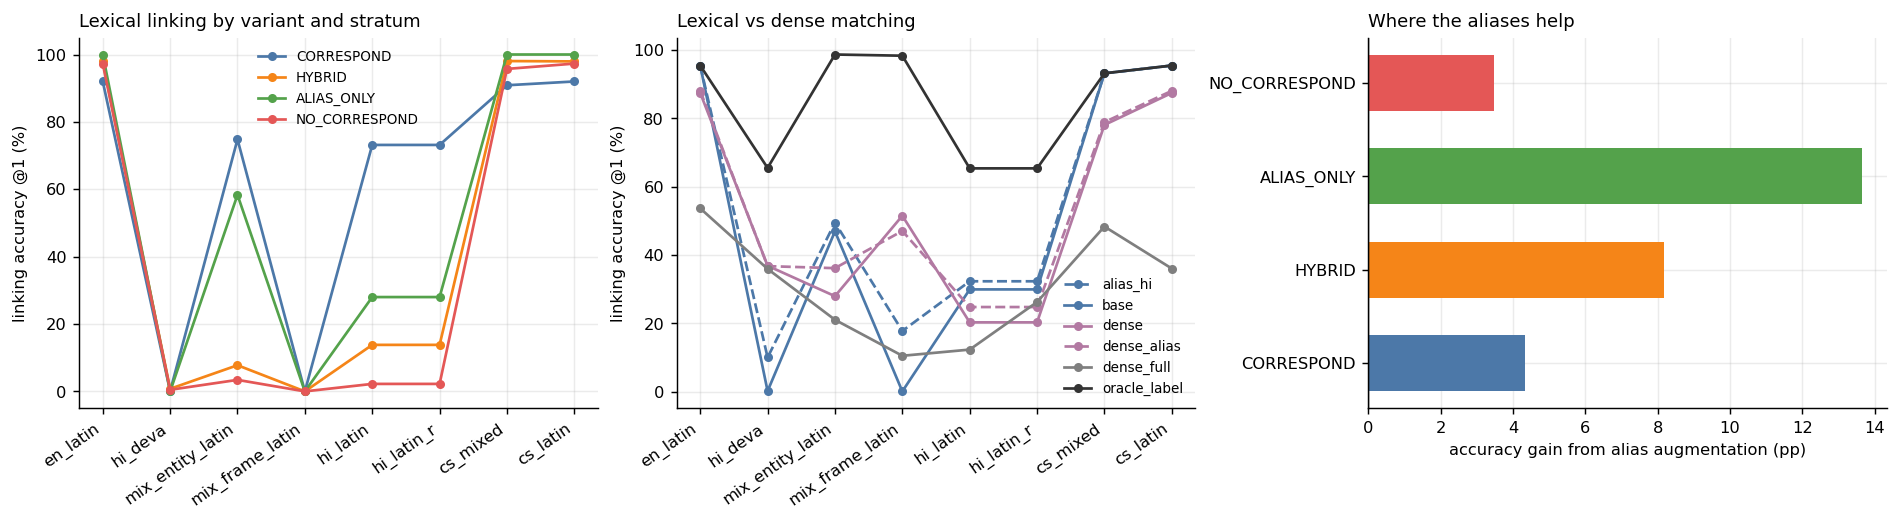

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.dpi": 130, "font.size": 9, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25,
    "grid.linestyle": "-", "axes.axisbelow": True,
})
# One hue per stratum, held constant across every figure so the reader learns it once.
PAL = {"CORRESPOND": "#4C78A8", "HYBRID": "#F58518", "ALIAS_ONLY": "#54A24B",
       "NO_CORRESPOND": "#E45756", "UNSCORABLE": "#9D9D9D"}

ARM_STYLE = {"base": ("#4C78A8", "-"), "alias_hi": ("#4C78A8", "--"),
             "dense": ("#B279A2", "-"), "dense_alias": ("#B279A2", "--"),
             "dense_full": ("#7F7F7F", "-")}

t = dfr[dfr.arm == "base"].pivot_table(index="variant", columns="stratum", values="hit1")
order = [c for c in VAR_COLS if c in t.index]
t = t.reindex(order)

fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.9), constrained_layout=True)

# 1 — the stratified result
for s in [c for c in ["CORRESPOND", "HYBRID", "ALIAS_ONLY", "NO_CORRESPOND"] if c in t.columns]:
    ax[0].plot(range(len(t)), 100 * t[s], marker="o", ms=4, color=PAL[s], label=s)
ax[0].set_xticks(range(len(t)))
ax[0].set_xticklabels(t.index, rotation=35, ha="right")
ax[0].set_ylabel("linking accuracy @1 (%)")
ax[0].set_title("Lexical linking by variant and stratum", loc="left", fontsize=10)
ax[0].legend(frameon=False, fontsize=7.5)

# 2 — lexical vs dense, the arm comparison
u = dfr.pivot_table(index="variant", columns="arm", values="hit1")
u = u.reindex([c for c in VAR_COLS if c in u.index])
for arm in [a for a in ARMS if a in u.columns]:
    col, ls = ARM_STYLE.get(arm, ("#333", "-"))
    ax[1].plot(range(len(u)), 100 * u[arm], marker="o", ms=4,
               color=col, linestyle=ls, label=arm)
ax[1].set_xticks(range(len(u)))
ax[1].set_xticklabels(u.index, rotation=35, ha="right")
ax[1].set_ylabel("linking accuracy @1 (%)")
ax[1].set_title("Lexical vs dense matching", loc="left", fontsize=10)
ax[1].legend(frameon=False, fontsize=7.5)

# 3 — where the aliases help
if "gain" in piv.columns:
    g = (100 * piv.groupby("stratum")["gain"].mean()).dropna()
    g = g.reindex([s for s in ["CORRESPOND", "HYBRID", "ALIAS_ONLY", "NO_CORRESPOND"]
                   if s in g.index])
    ax[2].barh(range(len(g)), g.values,
               color=[PAL[s] for s in g.index], height=.6)
    ax[2].set_yticks(range(len(g)))
    ax[2].set_yticklabels(g.index)
    ax[2].axvline(0, color="#333", lw=.8)
    ax[2].set_xlabel("accuracy gain from alias augmentation (pp)")
    ax[2].set_title("Where the aliases help", loc="left", fontsize=10)
plt.savefig("fig_linking.png", bbox_inches="tight")
plt.show()

In [ ]:
pd.DataFrame(VARIANTS).to_csv("variants_full.csv", index=False)
dfr.to_csv("linking_results.csv", index=False)
dfe.to_csv("failure_stages.csv", index=False)
pd.DataFrame([{k: v for k, v in s.items() if k != "per_word"}
              for s in STRATA.values()]).to_csv("qid_strata.csv", index=False)
if JA_OK and JA_RESULTS:
    pd.DataFrame(JA_RESULTS).to_csv("japanese_results.csv", index=False)
if len(ALIGN):
    ALIGN.to_csv("alignment_cosine.csv", index=False)

flat = []
for v in VARIANTS:
    for c in VAR_COLS:
        if v.get(c):
            flat.append({"id": v["id"], "variant": c, "text": v[c],
                         "qid": v["qid"], "stratum": v["stratum"],
                         "complexity": v.get("complexity"),
                         "surface_inflected": v["surface_inflected"],
                         "cmi": v.get(f"cmi_{c}"), "n_words": v.get(f"n_words_{c}"),
                         **{k: v.get(f"{k}_{c}") for k in
                            ("fert_e5-en", "fert_e5-mul", "fert_muril")}})
pd.DataFrame(flat).to_csv("cs_variants_flat.csv", index=False)
with open("cs_variants.json", "w", encoding="utf-8") as fh:
    json.dump(VARIANTS, fh, ensure_ascii=False, indent=1)

print("wrote: variants_full.csv, cs_variants_flat.csv, cs_variants.json,")
print("       linking_results.csv, failure_stages.csv, qid_strata.csv, fig_linking.png")

wrote: variants_full.csv, cs_variants_flat.csv, cs_variants.json,
       linking_results.csv, failure_stages.csv, qid_strata.csv, fig_linking.png


## Before writing this up

1. **Check the stratum sizes.** Anything under ~30 items cannot carry a claim
   about its effect size. If `NO_CORRESPOND` or `HYBRID` is thin, narrow the
   abstract before running anything else.
2. **Do not claim anything about native Indic entities from this dataset.** There
   are roughly fifteen, and most have English labels that *are* romanisations, so
   romanisation helps them. Mintaka is translated from English questions about
   largely Western subjects and has almost no Indic entity inventory.
3. **Report the trivial-match rate** alongside the alias gain, and say that the
   primary alias arm uses only Wikidata's human-written aliases.
4. **Report `CORR_T` and its sensitivity sweep**, since it is the one free
   parameter in the analysis.
5. **Say that linking is against a closed candidate set.** Absolute accuracies
   are upper bounds; the contrasts are what the claims rest on.
6. **Fix the abstract's alias sentence.** Mintaka does not supply
   `madhumeh/madhumeha/madhumeh bimari`-style romanised aliases at scale — which
   is why a romanizer exists in this project at all. As written, a reviewer will
   read it as "the romanised forms came from the dataset".
7. **Add the verbalisation caveat.** "After mapping to a QID the system no longer
   cares about language" is true for traversal but not for verbalisation; facts
   leave the graph as labels and labels have a language. Hence the
   English-only verbalisation control in Part 9.